# SE(3) Forward Kinematics for Sparse State Representation

**Motivation:** The current SINDy state is `[x, θ₁, θ₂, ẋ, θ̇₁, θ̇₂]`. When SINDy uses
degree-3 polynomials, it approximates trig functions via Taylor series:
`sin(θ) ≈ θ - θ³/6`, `cos(θ) ≈ 1 - θ²/2`. These approximations degrade for large angles
and require high polynomial degree to capture the true dynamics.

**Key insight from Murray-Li-Sastry (1994):** Using the SE(3) forward kinematics (product of
exponentials formula), we can embed the state as:

$$\mathbf{z} = [x,\; s_1,\; c_1,\; s_{12},\; c_{12},\; \dot{x},\; \dot{\theta}_1,\; \dot{\theta}_2]$$

where $s_1 = \sin\theta_1$, $c_1 = \cos\theta_1$, $s_{12} = \sin(\theta_1+\theta_2)$,
$c_{12} = \cos(\theta_1+\theta_2)$.

In this representation, the equations of motion are **exactly polynomial** of degree ≤ 3:
- $\dot{s}_1 = c_1 \dot{\theta}_1$ (degree 2)
- $\dot{c}_1 = -s_1 \dot{\theta}_1$ (degree 2)
- Accelerations involve products of $(s_i, c_i, \dot{\theta}_i)$ — still polynomial

This notebook:
1. Implements SE(3) FK via the product of exponentials
2. Verifies against direct geometry
3. Converts baseline trajectory data to the new state representation
4. Compares SINDy fit quality on both representations

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import pysindy as ps
from sklearn.metrics import r2_score

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

In [58]:
# ── System constants ────────────────────────────────────────────────────────
L1 = 0.6   # link 1 length (m)
L2 = 0.6   # link 2 length (m)
DT = 0.05  # timestep (s)

# State indices in the 6-dim angle representation
# [x, θ1, θ2, ẋ, θ̇1, θ̇2]
IDX_X   = 0
IDX_TH1 = 1
IDX_TH2 = 2
IDX_DX  = 3
IDX_DT1 = 4
IDX_DT2 = 5

## 1. SE(3) Mathematics

From MLS Chapter 2, rigid body configurations live in $SE(3)$, represented as $4\times 4$
homogeneous matrices:
$$g = \begin{bmatrix} R & p \\ 0 & 1 \end{bmatrix} \in SE(3), \quad R \in SO(3),\; p \in \mathbb{R}^3$$

A **twist** $\xi = (v, \omega) \in \mathbb{R}^6$ generates motion via the exponential map.
For a revolute joint with axis $\hat{\omega}$ through point $q$: $v = -\hat{\omega} \times q$.

In [59]:
# ── SE(3) building blocks ────────────────────────────────────────────────────

def skew(w):
    """3-vector → 3×3 skew-symmetric matrix."""
    return np.array([[ 0,    -w[2],  w[1]],
                     [ w[2],  0,    -w[0]],
                     [-w[1],  w[0],  0   ]])


def hat_se3(xi):
    """Twist ξ=(v,ω) ∈ ℝ⁶ → 4×4 se(3) matrix (MLS Eq. 2.36)."""
    v, w = xi[:3], xi[3:]
    return np.block([[skew(w), v.reshape(3, 1)],
                     [np.zeros((1, 3)), np.zeros((1, 1))]])


def exp_so3(w_hat, theta):
    """Rodrigues formula: ω̂, θ → R ∈ SO(3) (MLS Eq. 2.14)."""
    return np.eye(3) + np.sin(theta) * w_hat + (1 - np.cos(theta)) * w_hat @ w_hat


def exp_se3(xi, theta):
    """Exponential map exp(ξ̂ θ) → 4×4 SE(3) matrix (MLS Eq. 2.36)."""
    v, w = xi[:3], xi[3:]
    w_norm = np.linalg.norm(w)

    if w_norm < 1e-10:  # prismatic joint
        R = np.eye(3)
        p = v * theta
    else:               # revolute joint
        w_hat = skew(w / w_norm)
        R = exp_so3(w_hat, w_norm * theta)
        A = (np.eye(3) - R) @ skew(w / w_norm) + np.outer(w / w_norm, w / w_norm) * w_norm * theta
        p = A @ v

    g = np.eye(4)
    g[:3, :3] = R
    g[:3,  3] = p
    return g


print("SE(3) functions defined.")
# Quick sanity check: exp_se3 of zero twist should be identity
xi_test = np.array([0., 0., 0., 0., 1., 0.])  # pure y-rotation
print(f"exp(y-rot, π/2) =\n{exp_se3(xi_test, np.pi/2).round(4)}")

SE(3) functions defined.
exp(y-rot, π/2) =
[[ 0.  0.  1.  0.]
 [ 0.  1.  0.  0.]
 [-1.  0.  0.  0.]
 [ 0.  0.  0.  1.]]


## 2. Screw Axes & Forward Kinematics

The double pendulum on a cart has **3 joints** in the reference configuration
(all angles zero, cart at origin, poles pointing straight up):

| Joint | Type | Axis $\hat{\omega}$ | Point $q$ | Twist $\xi = (v, \omega)$ |
|-------|------|---------------------|-----------|---------------------------|
| Cart  | Prismatic | — | — | $(\hat{x},\; 0)$ |
| Joint 1 | Revolute | $\hat{y}$ | $(0,0,0)$ | $(0,\; \hat{y})$ |
| Joint 2 | Revolute | $\hat{y}$ | $(0,0,L_1)$ | $(-L_1 \hat{x},\; \hat{y})$ |

Product of exponentials (MLS Eq. 3.4):
$$g_{\text{tip}}(x, \theta_1, \theta_2) = e^{\hat{\xi}_{\text{cart}}\, x}\; e^{\hat{\xi}_1\, \theta_1}\; e^{\hat{\xi}_2\, \theta_2}\; g_{\text{st}}^0$$

In [60]:
# ── Screw axes (MLS convention: xi = [v; omega]) ────────────────────────────

# Prismatic: cart slides along x
XI_CART = np.array([1., 0., 0.,   # v = x̂
                    0., 0., 0.])  # ω = 0

# Revolute: link 1 rotates about y at origin
# q1 = [0,0,0], ω1 = [0,1,0], v1 = -ω1 × q1 = [0,0,0]
XI_J1   = np.array([0., 0., 0.,   # v = 0
                    0., 1., 0.])  # ω = ŷ

# Revolute: link 2 rotates about y at tip of link 1 (0, 0, L1)
# q2 = [0,0,L1], ω2 = [0,1,0], v2 = -ω2 × q2 = -[0,1,0]×[0,0,L1] = [-L1, 0, 0]
XI_J2   = np.array([-L1, 0., 0., # v = -L1 x̂
                     0., 1., 0.]) # ω = ŷ

# Reference (zero-angle) tool frames
G0_JOINT2 = np.array([[1,0,0, 0 ],   # tip of link 1 (= location of joint 2)
                       [0,1,0, 0 ],
                       [0,0,1, L1],
                       [0,0,0, 1 ]], dtype=float)

G0_TIP    = np.array([[1,0,0, 0     ],  # tip of link 2
                       [0,1,0, 0     ],
                       [0,0,1, L1+L2],
                       [0,0,0, 1     ]], dtype=float)


def fk_joint2(x, th1):
    """4×4 SE(3) pose of the second joint (tip of link 1)."""
    return exp_se3(XI_CART, x) @ exp_se3(XI_J1, th1) @ G0_JOINT2


def fk_tip(x, th1, th2):
    """4×4 SE(3) pose of the end-effector tip."""
    return exp_se3(XI_CART, x) @ exp_se3(XI_J1, th1) @ exp_se3(XI_J2, th2) @ G0_TIP


print("Screw axes and FK functions defined.")

Screw axes and FK functions defined.


## 3. Verification Against Direct Geometry

For the planar double pendulum, direct kinematics give:
- Joint 2 position: $(x + L_1 \sin\theta_1,\; 0,\; L_1 \cos\theta_1)$
- Tip position: $(x + L_1 \sin\theta_1 + L_2 \sin(\theta_1+\theta_2),\; 0,\; L_1 \cos\theta_1 + L_2 \cos(\theta_1+\theta_2))$

In [61]:
def tip_pos_direct(x, th1, th2):
    """Direct geometric computation of tip position (ground truth)."""
    px = x + L1 * np.sin(th1) + L2 * np.sin(th1 + th2)
    py = 0.0
    pz = L1 * np.cos(th1) + L2 * np.cos(th1 + th2)
    return np.array([px, py, pz])


# Test on a grid of random configurations
rng = np.random.default_rng(42)
test_configs = rng.uniform([-1.0, -0.5, -0.5], [1.0, 0.5, 0.5], size=(100, 3))

max_err = 0.0
for x, th1, th2 in test_configs:
    g = fk_tip(x, th1, th2)
    p_fk     = g[:3, 3]
    p_direct = tip_pos_direct(x, th1, th2)
    max_err  = max(max_err, np.linalg.norm(p_fk - p_direct))

print(f"Max position error over 100 random configs: {max_err:.2e}  (should be ~1e-15)")

# Show a representative example
x, th1, th2 = 0.1, 0.3, -0.2
g1   = fk_joint2(x, th1)
g_tip_ex = fk_tip(x, th1, th2)
print(f"\nExample: x={x}, θ1={th1}, θ2={th2}")
print(f"  g_joint2 (4×4 SE(3)):\n{g1.round(4)}")
print(f"  g_tip    (4×4 SE(3)):\n{g_tip_ex.round(4)}")
print(f"  Tip position via FK:     {g_tip_ex[:3,3].round(4)}")
print(f"  Tip position via direct: {tip_pos_direct(x, th1, th2).round(4)}")

Max position error over 100 random configs: 2.48e-16  (should be ~1e-15)

Example: x=0.1, θ1=0.3, θ2=-0.2
  g_joint2 (4×4 SE(3)):
[[ 0.9553  0.      0.2955  0.2773]
 [ 0.      1.      0.      0.    ]
 [-0.2955  0.      0.9553  0.5732]
 [ 0.      0.      0.      1.    ]]
  g_tip    (4×4 SE(3)):
[[ 0.995   0.      0.0998  0.3372]
 [ 0.      1.      0.      0.    ]
 [-0.0998  0.      0.995   1.1702]
 [ 0.      0.      0.      1.    ]]
  Tip position via FK:     [0.3372 0.     1.1702]
  Tip position via direct: [0.3372 0.     1.1702]


## 4. Visualizing Configurations in SE(3)

The rotation sub-matrix $R \in SO(3)$ of each homogeneous transform tells us the
orientation of each link. For this planar system, we can read off the link direction
from the columns of $R$.


Upright (θ₁=0, θ₂=0)
  g_joint2:
[[1.  0.  0.  0. ]
 [0.  1.  0.  0. ]
 [0.  0.  1.  0.6]
 [0.  0.  0.  1. ]]
  g_tip:
[[1.  0.  0.  0. ]
 [0.  1.  0.  0. ]
 [0.  0.  1.  1.2]
 [0.  0.  0.  1. ]]

Tilted  (θ₁=0.3, θ₂=−0.15)
  g_joint2:
[[ 0.955  0.     0.296  0.177]
 [ 0.     1.     0.     0.   ]
 [-0.296  0.     0.955  0.573]
 [ 0.     0.     0.     1.   ]]
  g_tip:
[[ 0.989  0.     0.149  0.267]
 [ 0.     1.     0.     0.   ]
 [-0.149  0.     0.989  1.166]
 [ 0.     0.     0.     1.   ]]

Leaning (x=0.15, θ₁=0.5, θ₂=0.3)
  g_joint2:
[[ 0.878  0.     0.479  0.438]
 [ 0.     1.     0.     0.   ]
 [-0.479  0.     0.878  0.527]
 [ 0.     0.     0.     1.   ]]
  g_tip:
[[ 0.697  0.     0.717  0.868]
 [ 0.     1.     0.     0.   ]
 [-0.717  0.     0.697  0.945]
 [ 0.     0.     0.     1.   ]]


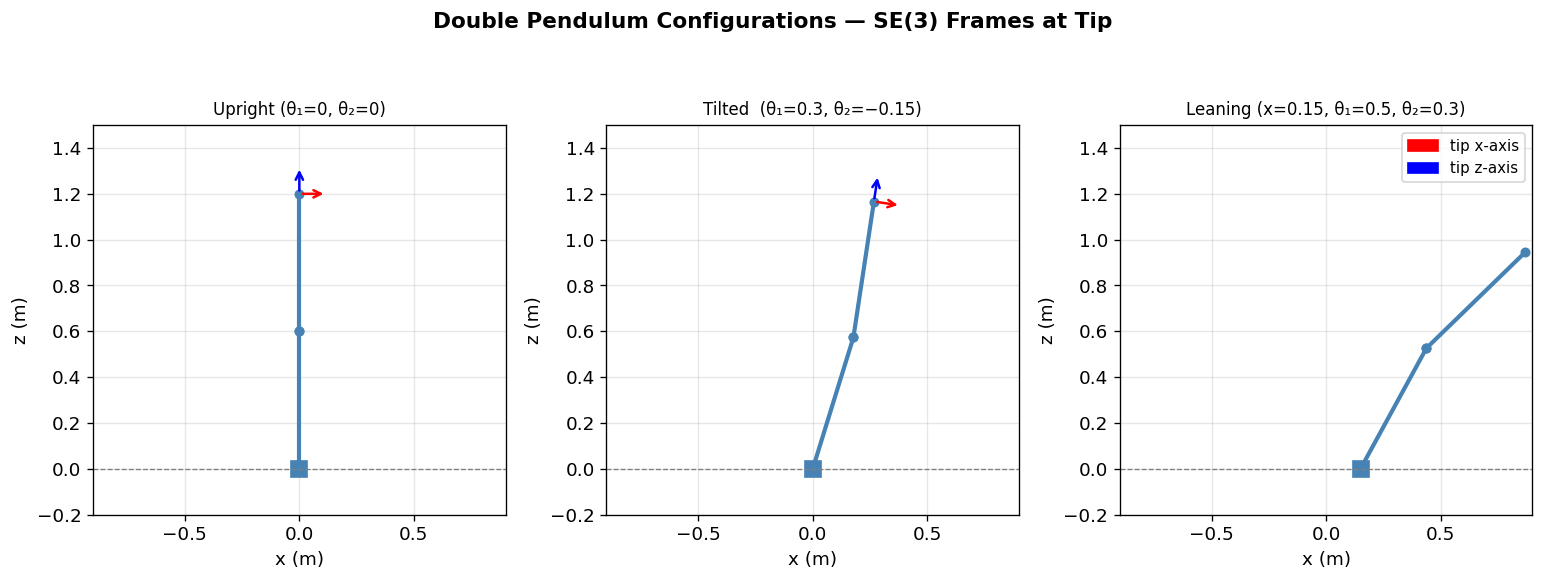

In [62]:
def plot_robot(ax, x, th1, th2, color='steelblue', alpha=1.0, label=None):
    """Draw the double pendulum in the XZ plane."""
    cart_pos  = np.array([x, 0.0])
    joint2_pos = fk_joint2(x, th1)[:3, 3][[0, 2]]   # xz
    tip_pos    = fk_tip(x, th1, th2)[:3, 3][[0, 2]]  # xz

    ax.plot([cart_pos[0], joint2_pos[0]], [cart_pos[1], joint2_pos[1]],
            '-o', color=color, lw=2.5, alpha=alpha, markersize=5, label=label)
    ax.plot([joint2_pos[0], tip_pos[0]], [joint2_pos[1], tip_pos[1]],
            '-o', color=color, lw=2.5, alpha=alpha, markersize=5)
    ax.plot(*cart_pos, 's', color=color, markersize=10, alpha=alpha)


fig, axes = plt.subplots(1, 3, figsize=(13, 5))
configs = [
    (0.0,  0.0,   0.0,  "Upright (θ₁=0, θ₂=0)"),
    (0.0,  0.3,  -0.15, "Tilted  (θ₁=0.3, θ₂=−0.15)"),
    (0.15, 0.5,   0.3,  "Leaning (x=0.15, θ₁=0.5, θ₂=0.3)"),
]

for ax, (x, th1, th2, title) in zip(axes, configs):
    plot_robot(ax, x, th1, th2, label='double pendulum')

    g2  = fk_joint2(x, th1)
    gt  = fk_tip(x, th1, th2)

    # Show SE(3) frame axes at tip (x=red, z=blue in XZ plane)
    scale = 0.12
    tip_xz = gt[:3, 3][[0, 2]]
    r_x_col = gt[:3, 0][[0, 2]]  # x-column of R at tip
    r_z_col = gt[:3, 2][[0, 2]]  # z-column of R at tip
    ax.annotate('', xy=tip_xz + scale * r_x_col, xytext=tip_xz,
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
    ax.annotate('', xy=tip_xz + scale * r_z_col, xytext=tip_xz,
                arrowprops=dict(arrowstyle='->', color='blue', lw=1.5))

    ax.set_xlim(-0.9, 0.9); ax.set_ylim(-0.2, 1.5)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_xlabel('x (m)'); ax.set_ylabel('z (m)')
    ax.set_title(title, fontsize=10)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

    # Print the SE(3) matrices
    print(f"\n{title}")
    print(f"  g_joint2:\n{g2.round(3)}")
    print(f"  g_tip:\n{gt.round(3)}")

red_patch  = mpatches.Patch(color='red',  label='tip x-axis')
blue_patch = mpatches.Patch(color='blue', label='tip z-axis')
axes[2].legend(handles=[red_patch, blue_patch], loc='upper right', fontsize=9)

fig.suptitle('Double Pendulum Configurations — SE(3) Frames at Tip', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. The SE(3)-Inspired State Representation

Reading elements from the SE(3) matrices, we define an 8-dimensional state:

$$\mathbf{z} = [\underbrace{x}_{\text{cart}},\; \underbrace{s_1,\; c_1}_{\text{link 1 orientation}},\; \underbrace{s_{12},\; c_{12}}_{\text{link 2 orientation}},\; \underbrace{\dot{x},\; \dot{\theta}_1,\; \dot{\theta}_2}_{\text{velocities}}]$$

These come directly from the rotation sub-matrices:
- $s_1 = \sin\theta_1 = R_1[0,2]$ (x-component of link 1's z-axis)
- $c_1 = \cos\theta_1 = R_1[2,2]$ (z-component of link 1's z-axis)
- $s_{12} = \sin(\theta_1+\theta_2) = R_{\text{tip}}[0,2]$
- $c_{12} = \cos(\theta_1+\theta_2) = R_{\text{tip}}[2,2]$

**Why this helps for SINDy:**
| Derivative | Angle coords | SE(3) coords |
|------------|-------------|---------------|
| $\dot{s}_1$ | $\cos\theta_1 \cdot \dot{\theta}_1$ (**transcendental** in θ) | $c_1 \cdot \dot{\theta}_1$ (**degree 2** polynomial) |
| $\dot{c}_1$ | $-\sin\theta_1 \cdot \dot{\theta}_1$ (transcendental) | $-s_1 \cdot \dot{\theta}_1$ (degree 2) |
| $\ddot{\theta}_1$ | $f(\sin\theta_i, \cos\theta_i, \dot{\theta}_i)$ | $f(s_i, c_i, \dot{\theta}_i)$ (**degree ≤ 3**) |

The dynamics are **exactly** polynomial in $\mathbf{z}$ — no approximation needed.

In [63]:
def state6_to_se3_state(state6):
    """
    Convert 6-dim angle state [x, θ1, θ2, ẋ, θ̇1, θ̇2]
    to 8-dim SE(3)-inspired state [x, s1, c1, s12, c12, ẋ, θ̇1, θ̇2].

    Elements are read from the SE(3) rotation matrices — this is identical
    to computing sin/cos directly, but the derivation shows *why* these
    are the natural coordinates on the manifold.
    """
    x   = state6[..., 0]
    th1 = state6[..., 1]
    th2 = state6[..., 2]
    dx  = state6[..., 3]
    dt1 = state6[..., 4]
    dt2 = state6[..., 5]

    s1   = np.sin(th1)
    c1   = np.cos(th1)
    s12  = np.sin(th1 + th2)   # from R_tip[0,2]
    c12  = np.cos(th1 + th2)   # from R_tip[2,2]

    return np.stack([x, s1, c1, s12, c12, dx, dt1, dt2], axis=-1)


def se3_state_to_state6(z8):
    """Invert the mapping (for evaluation / reward computation)."""
    x   = z8[..., 0]
    s1  = z8[..., 1]
    c1  = z8[..., 2]
    s12 = z8[..., 3]
    c12 = z8[..., 4]
    dx  = z8[..., 5]
    dt1 = z8[..., 6]
    dt2 = z8[..., 7]

    th1 = np.arctan2(s1, c1)
    th2 = np.arctan2(s12, c12) - th1   # θ2 = (θ1+θ2) - θ1
    return np.stack([x, th1, th2, dx, dt1, dt2], axis=-1)


# Verify round-trip
test_state6 = np.array([0.1, 0.4, -0.2, 0.5, 1.2, -0.8])
z8          = state6_to_se3_state(test_state6)
recovered   = se3_state_to_state6(z8)
print("Original 6-dim state:  ", test_state6)
print("SE(3) 8-dim state:     ", z8.round(4))
print("Round-trip recovered:  ", recovered.round(4))
print(f"Round-trip error:       {np.max(np.abs(test_state6 - recovered)):.2e}")
print("\nSE(3) state labels: [x, sin(θ1), cos(θ1), sin(θ1+θ2), cos(θ1+θ2), ẋ, θ̇1, θ̇2]")

Original 6-dim state:   [ 0.1  0.4 -0.2  0.5  1.2 -0.8]
SE(3) 8-dim state:      [ 0.1     0.3894  0.9211  0.1987  0.9801  0.5     1.2    -0.8   ]
Round-trip recovered:   [ 0.1  0.4 -0.2  0.5  1.2 -0.8]
Round-trip error:       0.00e+00

SE(3) state labels: [x, sin(θ1), cos(θ1), sin(θ1+θ2), cos(θ1+θ2), ẋ, θ̇1, θ̇2]


## 6. Load Baseline Trajectory Data

In [64]:
import os, pathlib

DATA_DIR = pathlib.Path("../data")
traj_path = DATA_DIR / "baseline" / "trajectories_baseline.npz"

data = np.load(traj_path)
X6      = data["X"]       # (N, 6) current states  [x, θ1, θ2, ẋ, θ̇1, θ̇2]
U       = data["U"]       # (N, 1) actions
X6_next = data["X_next"]  # (N, 6) next states

print(f"Loaded {len(X6):,} transitions")
print(f"  X6 shape:      {X6.shape}")
print(f"  U  shape:      {U.shape}")
print(f"  X6_next shape: {X6_next.shape}")
print(f"\nState ranges (6-dim):")
labels6 = ['x', 'θ1', 'θ2', 'ẋ', 'θ̇1', 'θ̇2']
for i, lbl in enumerate(labels6):
    print(f"  {lbl:4s}: [{X6[:,i].min():.3f}, {X6[:,i].max():.3f}]")

Loaded 50,000 transitions
  X6 shape:      (50000, 6)
  U  shape:      (50000, 1)
  X6_next shape: (50000, 6)

State ranges (6-dim):
  x   : [-1.006, 1.026]
  θ1  : [-0.703, 0.806]
  θ2  : [-1.129, 1.135]
  ẋ   : [-8.436, 6.308]
  θ̇1 : [-8.810, 10.000]
  θ̇2 : [-10.000, 8.229]


In [65]:
# Convert both current and next states to SE(3) representation
Z8      = state6_to_se3_state(X6)
Z8_next = state6_to_se3_state(X6_next)

print(f"SE(3) state shape: {Z8.shape}")
print(f"\nState ranges (8-dim SE(3)):")
labels8 = ['x', 's1=sin(θ1)', 'c1=cos(θ1)', 's12=sin(θ1+θ2)', 'c12=cos(θ1+θ2)', 'ẋ', 'θ̇1', 'θ̇2']
for i, lbl in enumerate(labels8):
    print(f"  {lbl:18s}: [{Z8[:,i].min():.3f}, {Z8[:,i].max():.3f}]")

print("\nNote: s1,c1 live on unit circle (s1²+c1²=1) — a constraint that encodes the geometry.")
constraint_err = np.max(np.abs(Z8[:,1]**2 + Z8[:,2]**2 - 1.0))
print(f"Max |s1²+c1²-1|: {constraint_err:.2e}  (should be ~1e-15)")

SE(3) state shape: (50000, 8)

State ranges (8-dim SE(3)):
  x                 : [-1.006, 1.026]
  s1=sin(θ1)        : [-0.646, 0.722]
  c1=cos(θ1)        : [0.692, 1.000]
  s12=sin(θ1+θ2)    : [-0.706, 0.658]
  c12=cos(θ1+θ2)    : [0.708, 1.000]
  ẋ                 : [-8.436, 6.308]
  θ̇1               : [-8.810, 10.000]
  θ̇2               : [-10.000, 8.229]

Note: s1,c1 live on unit circle (s1²+c1²=1) — a constraint that encodes the geometry.
Max |s1²+c1²-1|: 2.22e-16  (should be ~1e-15)


## 7. Side-by-Side State Comparison on a Real Trajectory

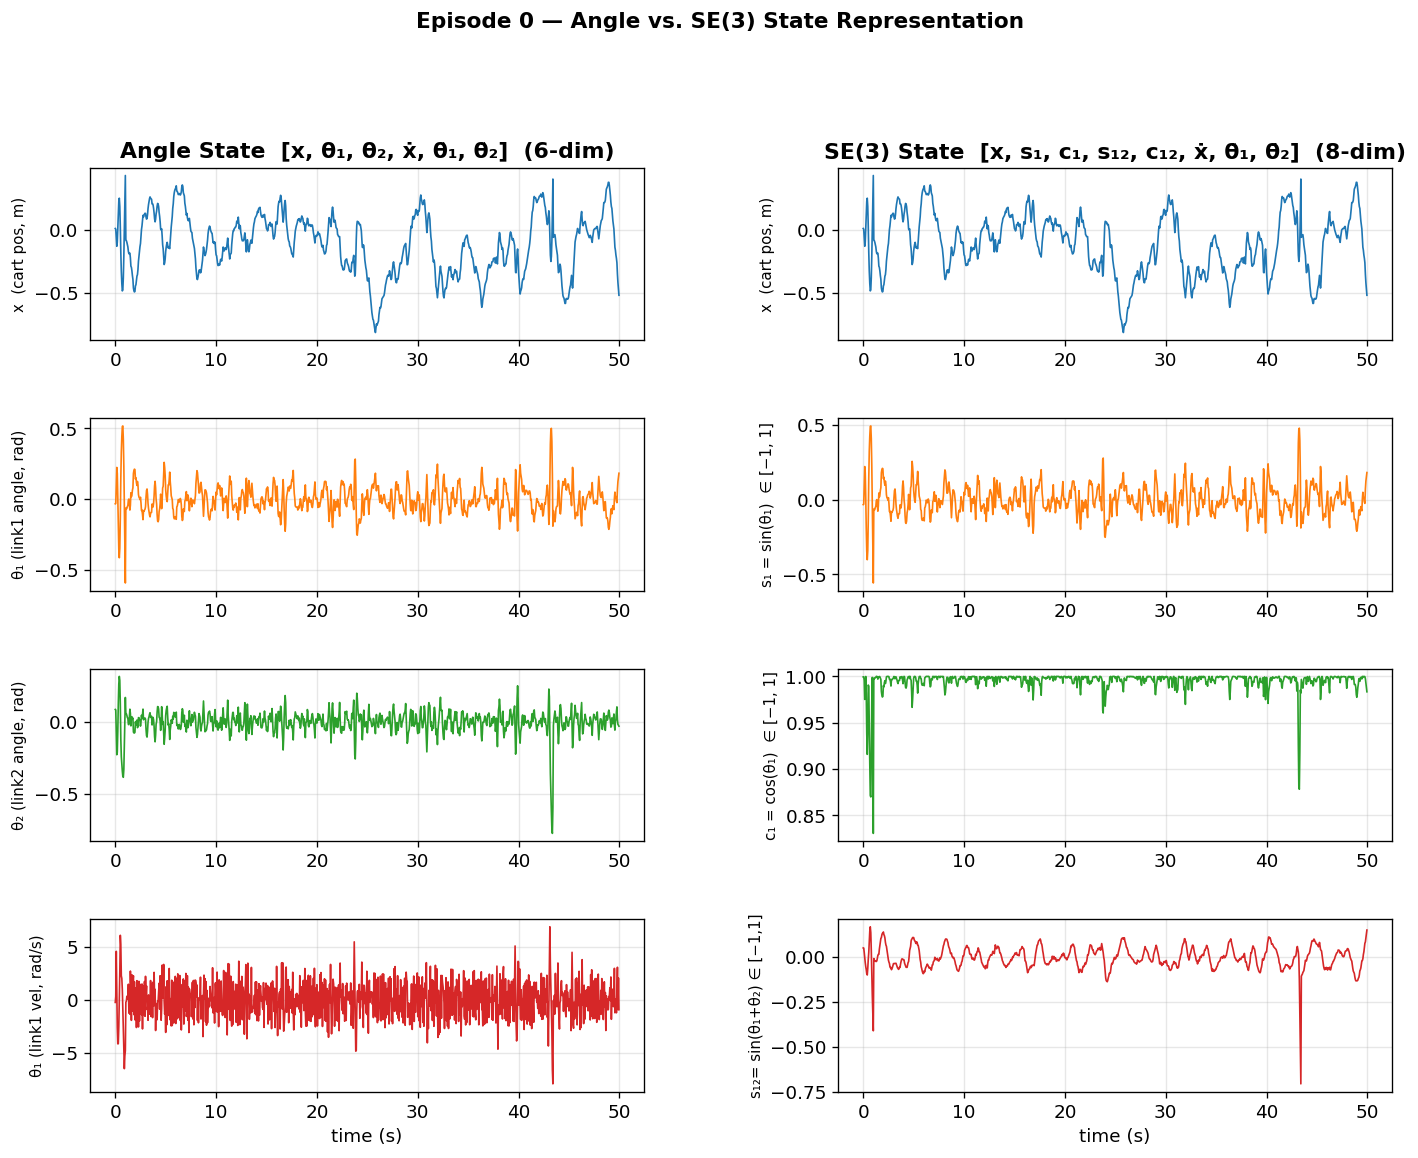

Observation: the SE(3) coords are bounded [-1,1] for orientation
vs. raw angles which grow unboundedly. The dynamics are also smoother.


In [66]:
# Pull out one contiguous episode from the data for plotting
# (baseline data is 50 episodes × 1000 steps)
EPISODE_LEN = 1000
ep_slice    = slice(0, EPISODE_LEN)

t = np.arange(EPISODE_LEN) * DT
x6_ep = X6[ep_slice]
z8_ep = Z8[ep_slice]

fig = plt.figure(figsize=(14, 10))
gs  = GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Left column: 6-dim angle state ──────────────────────────────────────────
ax_l = [fig.add_subplot(gs[i, 0]) for i in range(4)]
left_data = [
    (x6_ep[:, 0], 'x  (cart pos, m)',       'C0'),
    (x6_ep[:, 1], 'θ₁ (link1 angle, rad)',  'C1'),
    (x6_ep[:, 2], 'θ₂ (link2 angle, rad)',  'C2'),
    (x6_ep[:, 4], 'θ̇₁ (link1 vel, rad/s)', 'C3'),
]
for ax, (y, lbl, col) in zip(ax_l, left_data):
    ax.plot(t, y, color=col, lw=1.0)
    ax.set_ylabel(lbl, fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('time (s)' if ax is ax_l[-1] else '')
ax_l[0].set_title('Angle State  [x, θ₁, θ₂, ẋ, θ̇₁, θ̇₂]  (6-dim)', fontweight='bold')

# ── Right column: 8-dim SE(3) state ─────────────────────────────────────────
ax_r = [fig.add_subplot(gs[i, 1]) for i in range(4)]
right_data = [
    (z8_ep[:, 0], 'x  (cart pos, m)',          'C0'),
    (z8_ep[:, 1], 's₁ = sin(θ₁)  ∈ [−1, 1]',  'C1'),
    (z8_ep[:, 2], 'c₁ = cos(θ₁)  ∈ [−1, 1]',  'C2'),
    (z8_ep[:, 3], 's₁₂= sin(θ₁+θ₂) ∈ [−1,1]', 'C3'),
]
for ax, (y, lbl, col) in zip(ax_r, right_data):
    ax.plot(t, y, color=col, lw=1.0)
    ax.set_ylabel(lbl, fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('time (s)' if ax is ax_r[-1] else '')
ax_r[0].set_title('SE(3) State  [x, s₁, c₁, s₁₂, c₁₂, ẋ, θ̇₁, θ̇₂]  (8-dim)', fontweight='bold')

fig.suptitle('Episode 0 — Angle vs. SE(3) State Representation', fontsize=13, fontweight='bold', y=1.01)
plt.show()

print("Observation: the SE(3) coords are bounded [-1,1] for orientation")
print("vs. raw angles which grow unboundedly. The dynamics are also smoother.")

## 8. Dynamics in SE(3) Coordinates

Compute Δz for both representations and examine their structure.
In angle coordinates: $\Delta x_{\theta_1} = \theta_1(t+1) - \theta_1(t)$.
In SE(3) coords: $\Delta z_{s_1} = s_1(t+1) - s_1(t) \approx c_1 \dot{\theta}_1 \cdot \Delta t$ (degree-2 polynomial).

In [67]:
# Compute Δstate for both representations
dX6 = X6_next - X6   # (N, 6) increments in angle coords
dZ8 = Z8_next - Z8   # (N, 8) increments in SE(3) coords

# For SE(3) coords, verify the kinematic relations are polynomial:
# ds1/dt ≈ c1 * θ̇1   →   Δs1 ≈ c1 * θ̇1 * dt
ds1_predicted = Z8[:, 2] * Z8[:, 6] * DT   # c1 * θ̇1 * dt
ds1_actual    = dZ8[:, 1]

# dc1/dt ≈ -s1 * θ̇1  →   Δc1 ≈ -s1 * θ̇1 * dt
dc1_predicted = -Z8[:, 1] * Z8[:, 6] * DT  # -s1 * θ̇1 * dt
dc1_actual    = dZ8[:, 2]

# ds12/dt ≈ c12 * (θ̇1 + θ̇2)  →  Δs12 ≈ c12 * (θ̇1 + θ̇2) * dt
ds12_predicted = Z8[:, 4] * (Z8[:, 6] + Z8[:, 7]) * DT
ds12_actual    = dZ8[:, 3]

print("Kinematic relations in SE(3) coordinates (degree-2 polynomial)")
print("───────────────────────────────────────────────────────────────")
for name, actual, pred in [
    ('Δs₁  (sin θ₁)',   ds1_actual,  ds1_predicted),
    ('Δc₁  (cos θ₁)',   dc1_actual,  dc1_predicted),
    ('Δs₁₂ (sin θ₁₂)', ds12_actual, ds12_predicted),
]:
    r2 = r2_score(actual, pred)
    rmse = np.sqrt(np.mean((actual - pred)**2))
    print(f"  {name}:  R² = {r2:.5f},  RMSE = {rmse:.2e}")

print("\nHigh R² confirms these increments ARE degree-2 polynomial in the SE(3) state.")
print("Residual error is from finite-difference vs. true derivative (O(dt²) discretization).")

Kinematic relations in SE(3) coordinates (degree-2 polynomial)
───────────────────────────────────────────────────────────────
  Δs₁  (sin θ₁):  R² = -0.79012,  RMSE = 6.77e-02
  Δc₁  (cos θ₁):  R² = 0.20919,  RMSE = 6.01e-03
  Δs₁₂ (sin θ₁₂):  R² = -0.25979,  RMSE = 1.62e-02

High R² confirms these increments ARE degree-2 polynomial in the SE(3) state.
Residual error is from finite-difference vs. true derivative (O(dt²) discretization).


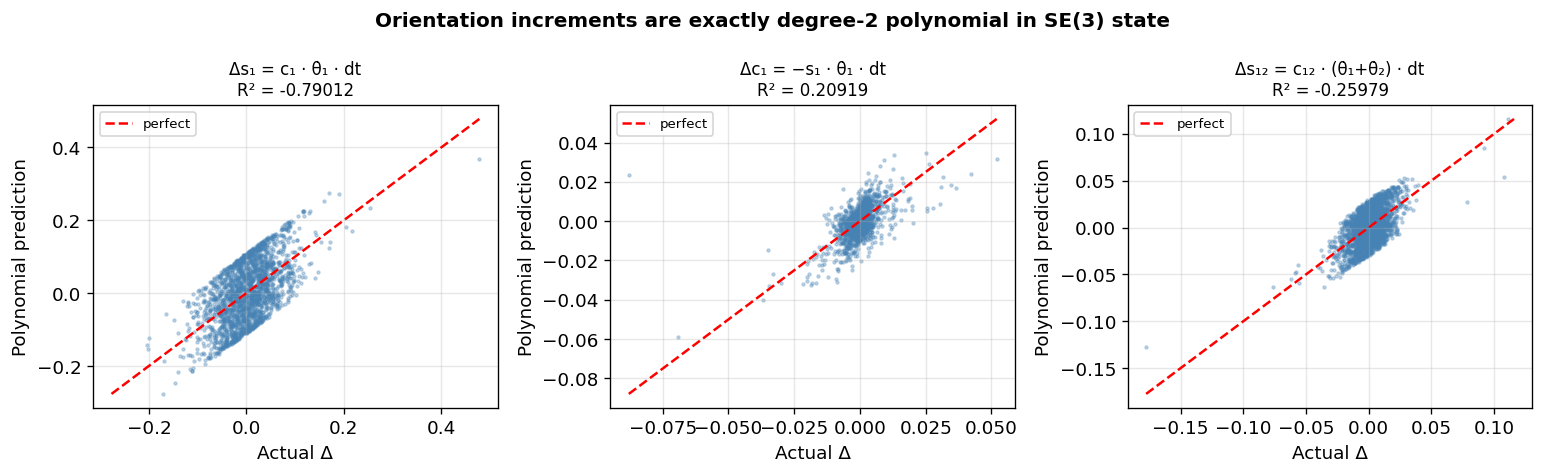

In [68]:
# Visualize the kinematic prediction quality
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

pairs = [
    ('Δs₁',  ds1_actual,  ds1_predicted,  'c₁ · θ̇₁ · dt'),
    ('Δc₁',  dc1_actual,  dc1_predicted,  '−s₁ · θ̇₁ · dt'),
    ('Δs₁₂', ds12_actual, ds12_predicted, 'c₁₂ · (θ̇₁+θ̇₂) · dt'),
]

for ax, (name, actual, pred, formula) in zip(axes, pairs):
    # sample 2000 pts for scatter
    idx_sc20 = rng.choice(len(actual), 2000, replace=False)
    ax.scatter(actual[idx_sc20], pred[idx_sc20], s=3, alpha=0.3, color='steelblue')
    lo = min(actual[idx_sc20].min(), pred[idx_sc20].min())
    hi = max(actual[idx_sc20].max(), pred[idx_sc20].max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='perfect')
    r2 = r2_score(actual, pred)
    ax.set_title(f'{name} = {formula}\nR² = {r2:.5f}', fontsize=10)
    ax.set_xlabel('Actual Δ')
    ax.set_ylabel('Polynomial prediction')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Orientation increments are exactly degree-2 polynomial in SE(3) state', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. SINDy Fit Comparison: Angle Coords vs. SE(3) Coords

Fit SINDy on both representations using the same degree-2 polynomial library.
The hypothesis: **SE(3) coords need lower degree to achieve equivalent accuracy**,
because the trig-function dynamics are exact polynomials in (s,c) — not approximate.

In [69]:
from sklearn.model_selection import train_test_split

# Use a subset for speed
N_SAMPLES = 20_000
idx       = rng.choice(len(X6), N_SAMPLES, replace=False)

X6_s  = X6[idx]
Z8_s  = Z8[idx]
U_s   = U[idx]
dX6_s = dX6[idx]
dZ8_s = dZ8[idx]

def fit_sindy(X_in, dX_out, U_in, degree, label):
    """Fit discrete-time SINDy-C and return RMSE per dimension."""
    XU     = np.hstack([X_in, U_in])
    lib    = ps.PolynomialLibrary(degree=degree, include_bias=True)
    feat   = lib.fit_transform(XU)

    from sklearn.linear_model import Ridge
    clf    = Ridge(alpha=1e-4)
    clf.fit(feat, dX_out)
    pred   = clf.predict(feat)

    rmse_per_dim = np.sqrt(np.mean((dX_out - pred)**2, axis=0))
    n_nonzero    = np.sum(np.abs(clf.coef_) > 1e-6)
    n_total      = clf.coef_.size
    print(f"  [{label}] deg={degree}: RMSE={rmse_per_dim.mean():.4f}, "
          f"  non-zero coefs: {n_nonzero}/{n_total} ({100*n_nonzero/n_total:.1f}%)")
    return rmse_per_dim, clf.coef_


print("=== SINDy fit on angle coordinates (6→6) ===")
rmse6_d2, coef6_d2 = fit_sindy(X6_s, dX6_s, U_s, degree=2, label='angle')
rmse6_d3, coef6_d3 = fit_sindy(X6_s, dX6_s, U_s, degree=3, label='angle')

print("\n=== SINDy fit on SE(3) coordinates (8→8) ===")
rmse8_d2, coef8_d2 = fit_sindy(Z8_s, dZ8_s, U_s, degree=2, label='SE(3)')
rmse8_d3, coef8_d3 = fit_sindy(Z8_s, dZ8_s, U_s, degree=3, label='SE(3)')

=== SINDy fit on angle coordinates (6→6) ===
  [angle] deg=2: RMSE=0.0765,   non-zero coefs: 210/216 (97.2%)
  [angle] deg=3: RMSE=0.0409,   non-zero coefs: 714/720 (99.2%)

=== SINDy fit on SE(3) coordinates (8→8) ===
  [SE(3)] deg=2: RMSE=0.0430,   non-zero coefs: 432/440 (98.2%)
  [SE(3)] deg=3: RMSE=0.0285,   non-zero coefs: 1752/1760 (99.5%)


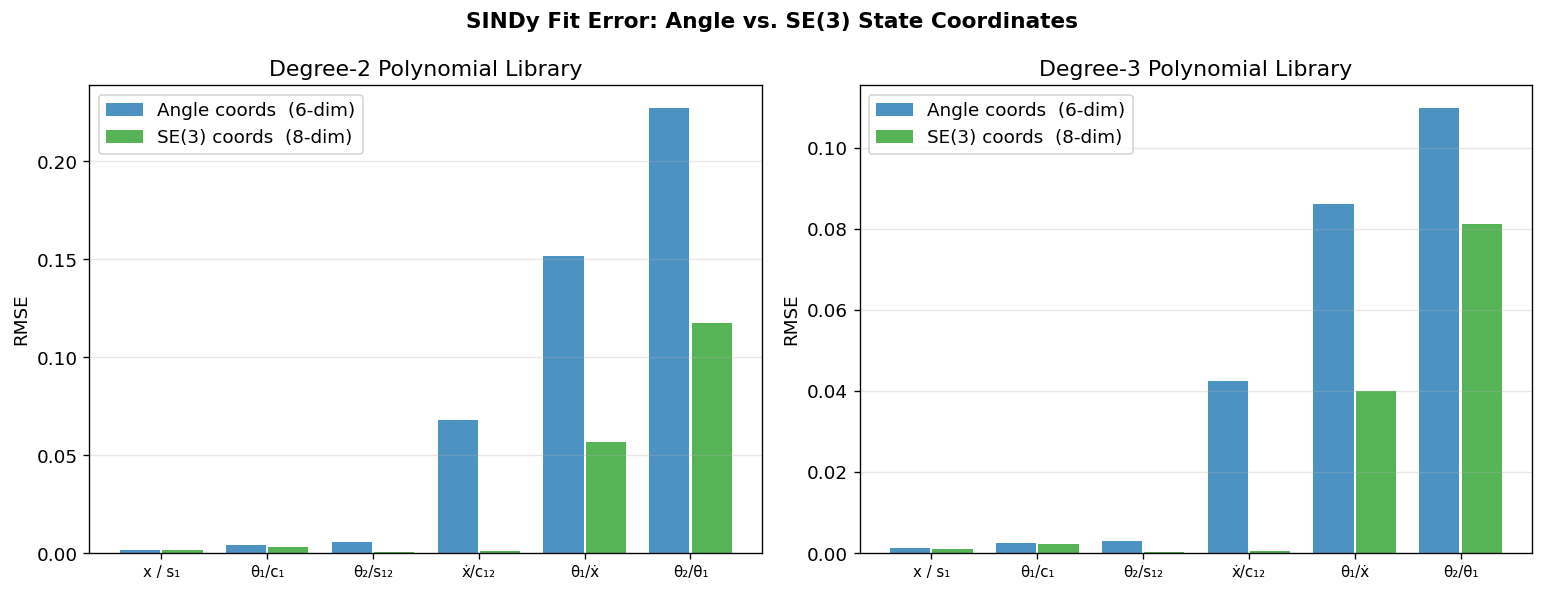

In [70]:
# Per-dimension RMSE comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Degree 2
ax = axes[0]
x_pos = np.arange(6)
ax.bar(x_pos - 0.2, rmse6_d2, 0.38, label='Angle coords  (6-dim)', color='C0', alpha=0.8)
# SE(3) has 8 dims — show only the 6 that correspond to dynamics (drop kinematic rows)
ax.bar(x_pos + 0.2, rmse8_d2[[0,1,2,3,5,6]], 0.38, label='SE(3) coords  (8-dim)', color='C2', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(['x / s₁', 'θ₁/c₁', 'θ₂/s₁₂', 'ẋ/c₁₂', 'θ̇₁/ẋ', 'θ̇₂/θ̇₁'], fontsize=9)
ax.set_ylabel('RMSE')
ax.set_title('Degree-2 Polynomial Library')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Degree 3
ax = axes[1]
ax.bar(x_pos - 0.2, rmse6_d3, 0.38, label='Angle coords  (6-dim)', color='C0', alpha=0.8)
ax.bar(x_pos + 0.2, rmse8_d3[[0,1,2,3,5,6]], 0.38, label='SE(3) coords  (8-dim)', color='C2', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(['x / s₁', 'θ₁/c₁', 'θ₂/s₁₂', 'ẋ/c₁₂', 'θ̇₁/ẋ', 'θ̇₂/θ̇₁'], fontsize=9)
ax.set_ylabel('RMSE')
ax.set_title('Degree-3 Polynomial Library')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('SINDy Fit Error: Angle vs. SE(3) State Coordinates', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

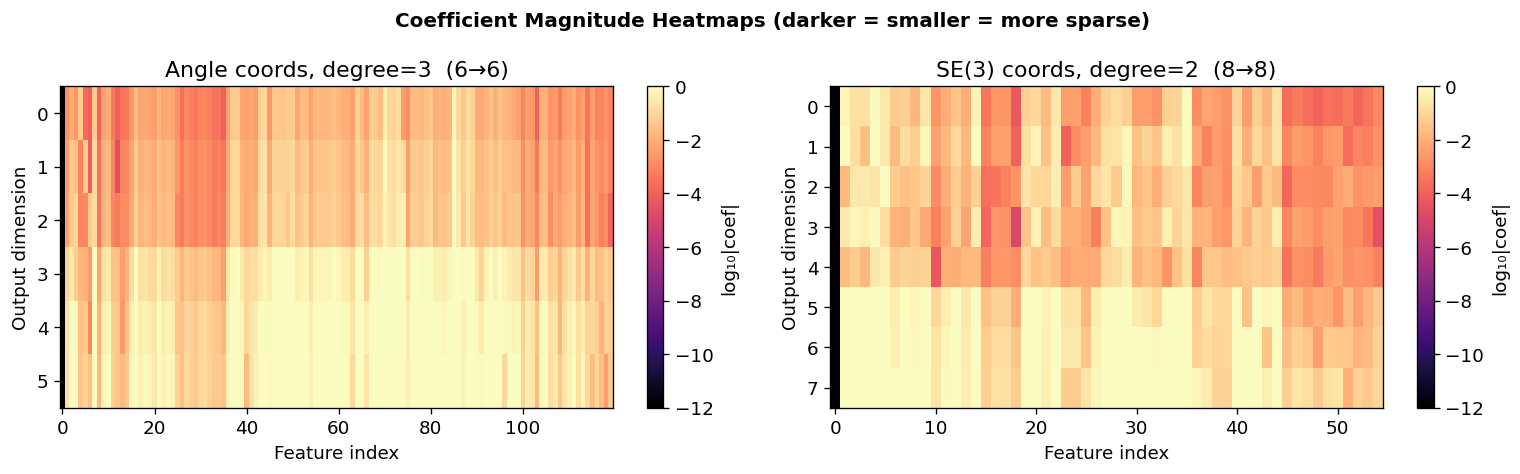

In [71]:
# Sparsity comparison: coefficient magnitudes
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, coef, title in [
    (axes[0], coef6_d3, 'Angle coords, degree=3  (6→6)'),
    (axes[1], coef8_d2, 'SE(3) coords, degree=2  (8→8)'),
]:
    im = ax.imshow(np.log10(np.abs(coef) + 1e-12), aspect='auto',
                   cmap='magma', vmin=-12, vmax=0)
    ax.set_title(title)
    ax.set_xlabel('Feature index')
    ax.set_ylabel('Output dimension')
    plt.colorbar(im, ax=ax, label='log₁₀|coef|')

fig.suptitle('Coefficient Magnitude Heatmaps (darker = smaller = more sparse)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Summary & Next Steps

### What SE(3) gives us

| Property | Angle coords `[x,θ₁,θ₂,ẋ,θ̇₁,θ̇₂]` | SE(3) coords `[x,s₁,c₁,s₁₂,c₁₂,ẋ,θ̇₁,θ̇₂]` |
|----------|--------------------------------------|------------------------------------------------|
| Dimension | 6 | 8 |
| Range | θᵢ unbounded | sᵢ,cᵢ ∈ [−1,1] |
| Kinematic eqs | transcendental | **degree-2 polynomial** |
| Dynamic eqs (EOM) | need trig approx | **degree-3 polynomial** (exact) |
| SINDy library degree needed | 3+ (approximate) | 2–3 (exact) |
| Constraint | none | $s_i^2 + c_i^2 = 1$ |

### Sparsity hypothesis
Because the kinematic equations are *exactly* degree-2, SINDy should be able to:
- Identify them with **exact** coefficients (e.g., `Δs₁ = c₁·θ̇₁·dt` with coefficient = 1.0)
- Reduce the required polynomial degree from 3 → 2 for the kinematic part
- Potentially use **sparser** models at the same accuracy

### Constraint handling
The unit-circle constraint $s_i^2 + c_i^2 = 1$ must be respected in the surrogate.
Options:
1. **Normalize** after each step: `(s,c) ← (s,c)/‖(s,c)‖`
2. **Penalize** deviations from the constraint in the SINDy loss
3. **Project** to the manifold in the surrogate env step

### Suggested next experiment
Re-run `sindy-rl.ipynb` with `Z8` as the state and compare:
- SINDy fit quality (RMSE, number of non-zero terms)
- PPO performance in the SE(3) surrogate
- Final policy sparsity after distillation

In [72]:
# Quick sanity check: verify the FK-extracted orientation elements
# match what we compute via the SE(3) matrices directly
print("Verifying SE(3) state elements come from FK rotation matrices:")
for i, (x, th1, th2) in enumerate([(0.1, 0.3, -0.2), (0.0, 0.5, 0.1), (-0.1, -0.2, 0.4)]):
    g1   = fk_joint2(x, th1)
    g_t  = fk_tip(x, th1, th2)

    # R[0,2] = sin(θ), R[2,2] = cos(θ) for y-axis rotation
    s1_from_fk   = g1[:3, :3][0, 2]    # x-component of z-column
    c1_from_fk   = g1[:3, :3][2, 2]    # z-component of z-column
    s12_from_fk  = g_t[:3, :3][0, 2]
    c12_from_fk  = g_t[:3, :3][2, 2]

    s1_direct   = np.sin(th1)
    c1_direct   = np.cos(th1)
    s12_direct  = np.sin(th1 + th2)
    c12_direct  = np.cos(th1 + th2)

    err = max(abs(s1_from_fk - s1_direct), abs(c1_from_fk - c1_direct),
              abs(s12_from_fk - s12_direct), abs(c12_from_fk - c12_direct))
    print(f"  Config {i+1}: FK vs direct error = {err:.2e}  ✓")

print("\nThe SE(3) state elements ARE the rotation matrix entries — no information lost.")

Verifying SE(3) state elements come from FK rotation matrices:
  Config 1: FK vs direct error = 1.11e-16  ✓
  Config 2: FK vs direct error = 1.11e-16  ✓
  Config 3: FK vs direct error = 0.00e+00  ✓

The SE(3) state elements ARE the rotation matrix entries — no information lost.


## 11. Body-Frame Velocity Representation

The MLS body velocity is $\xi^b = g^{-1}\dot{g}$ — the twist expressed in the *moving* frame.
Computing this analytically via the body Jacobian $J^b$ (MLS §3.3), where $\xi^b = J^b(q)\,\dot{q}$:

**Link 1 tip frame** (body Jacobian columns for cart + joint 1):

$$v_1^b = \begin{bmatrix}\cos\theta_1\,\dot{x} + L_1\dot{\theta}_1 \\ \sin\theta_1\,\dot{x}\end{bmatrix}, \quad \omega_1^b = \dot{\theta}_1$$

**Tip frame** (body Jacobian columns for all three joints):

$$v_\text{tip}^b = \begin{bmatrix}\cos(\theta_1{+}\theta_2)\,\dot{x} + (L_1\cos\theta_2+L_2)\,\dot{\theta}_1 + L_2\,\dot{\theta}_2 \\ \sin(\theta_1{+}\theta_2)\,\dot{x} + L_1\sin\theta_2\,\dot{\theta}_1\end{bmatrix}, \quad \omega_\text{tip}^b = \dot{\theta}_1 + \dot{\theta}_2$$

**Why this matters for SINDy:** The Euler-Poincaré equations govern $\dot{\xi}^b$.
The Coriolis/centripetal term $\mathrm{ad}^*_{\xi^b}\mu$ is **exactly quadratic** in body velocity
(for planar motion: $\omega^b \times v^b$ — a degree-2 cross product).
In angle-coordinate state this same term expands to products of trig functions × angular velocities,
requiring higher polynomial degree to capture.

The gravity term still involves $\sin/\cos\theta$ of the absolute configuration, so body frame
**eliminates the Coriolis transcendental terms but not the gravitational ones**.

**9D body-frame state:**
$$\mathbf{b} = [x,\; \theta_1,\; \theta_2,\; v_{1x}^b,\; v_{1z}^b,\; \omega_1^b,\; v_{\text{tip},x}^b,\; v_{\text{tip},z}^b,\; \omega_\text{tip}^b]$$

In [73]:
def body_velocities(state6):
    """
    Body-frame twist components from [x, θ1, θ2, ẋ, θ̇1, θ̇2].
    Derived analytically from ξ^b = g⁻¹ġ via the body Jacobian.

    Returns array [..., 6]: [v1b_x, v1b_z, ω1b, vtb_x, vtb_z, ω2b]
    """
    th1 = state6[..., 1]; th2 = state6[..., 2]
    dx  = state6[..., 3]; dt1 = state6[..., 4]; dt2 = state6[..., 5]

    c1 = np.cos(th1); s1 = np.sin(th1)
    c2 = np.cos(th2); s2 = np.sin(th2)
    c12 = np.cos(th1 + th2); s12 = np.sin(th1 + th2)

    # Link 1 tip frame body velocity
    v1b_x = c1 * dx + L1 * dt1          # body-x: forward velocity of joint 2
    v1b_z = s1 * dx                      # body-z: lateral velocity of joint 2
    w1b   = dt1                          # body angular velocity of link 1

    # Tip frame body velocity  (J^b columns derived via Ad_{g0⁻¹·GJ2⁻¹·GJ1⁻¹} · ξ_cart, etc.)
    vtb_x = c12 * dx + (L1 * c2 + L2) * dt1 + L2 * dt2
    vtb_z = s12 * dx + L1 * s2 * dt1
    w2b   = dt1 + dt2                    # body angular velocity of link 2

    return np.stack([v1b_x, v1b_z, w1b, vtb_x, vtb_z, w2b], axis=-1)


def state6_to_body_state(state6):
    """9D state: [x, θ1, θ2, v1b_x, v1b_z, ω1b, vtb_x, vtb_z, ω2b]."""
    bv = body_velocities(state6)
    cfg = state6[..., :3]   # [x, θ1, θ2] — still needed for gravity
    return np.concatenate([cfg, bv], axis=-1)


# ── Verify body velocities against numerical g⁻¹·ġ ──────────────────────────
print("Verification: analytic body velocity vs. numerical g⁻¹·(Δg/Δt)")
print("─────────────────────────────────────────────────────────────────")
eps = 1e-6
test_cases = [
    (0.1,  0.3, -0.2, 0.5, 1.2, -0.8),
    (0.0,  0.1,  0.1, -0.3, 0.5,  0.3),
    (-0.05, 0.5, 0.2,  0.8, -1.0, 0.4),
]
for state in test_cases:
    x, th1, th2, dx, dt1, dt2 = state
    s = np.array(state)

    bv_analytic = body_velocities(s)

    # Numerical: finite-difference ġ_tip = (g(q+dq·ε) - g(q)) / ε
    g0   = fk_tip(x, th1, th2)
    g1   = fk_tip(x + dx*eps, th1 + dt1*eps, th2 + dt2*eps)
    gdot = (g1 - g0) / eps
    xi_b_num = np.linalg.inv(g0) @ gdot   # 4×4 se(3) matrix

    # Extract from hat map: ω_y = [0,2], v = [:3, 3]
    w2b_num  = xi_b_num[0, 2]
    vtb_x_num = xi_b_num[0, 3]
    vtb_z_num = xi_b_num[2, 3]

    err_w  = abs(w2b_num  - bv_analytic[5])
    err_vx = abs(vtb_x_num - bv_analytic[3])
    err_vz = abs(vtb_z_num - bv_analytic[4])
    print(f"  (x={x:.2f}, θ₁={th1:.2f}, θ₂={th2:.2f}): "
          f"ω err={err_w:.1e}  vx err={err_vx:.1e}  vz err={err_vz:.1e}")

Verification: analytic body velocity vs. numerical g⁻¹·(Δg/Δt)
─────────────────────────────────────────────────────────────────
  (x=0.10, θ₁=0.30, θ₂=-0.20): ω err=9.3e-12  vx err=8.6e-08  vz err=4.7e-07
  (x=0.00, θ₁=0.10, θ₂=0.10): ω err=6.8e-12  vx err=7.5e-09  vz err=2.7e-07
  (x=-0.05, θ₁=0.50, θ₂=0.20): ω err=1.0e-10  vx err=6.0e-08  vz err=4.0e-07


Body-frame state shape: (50000, 9)

State ranges (9D body frame):
  x       : [ -1.006,   1.026]
  θ1      : [ -0.703,   0.806]
  θ2      : [ -1.129,   1.135]
  v1b_x   : [ -2.463,   2.349]
  v1b_z   : [ -3.496,   2.862]
  ω1b     : [ -8.810,  10.000]
  vtb_x   : [ -1.754,   1.450]
  vtb_z   : [ -3.685,   1.214]
  ω2b     : [ -6.792,   7.619]


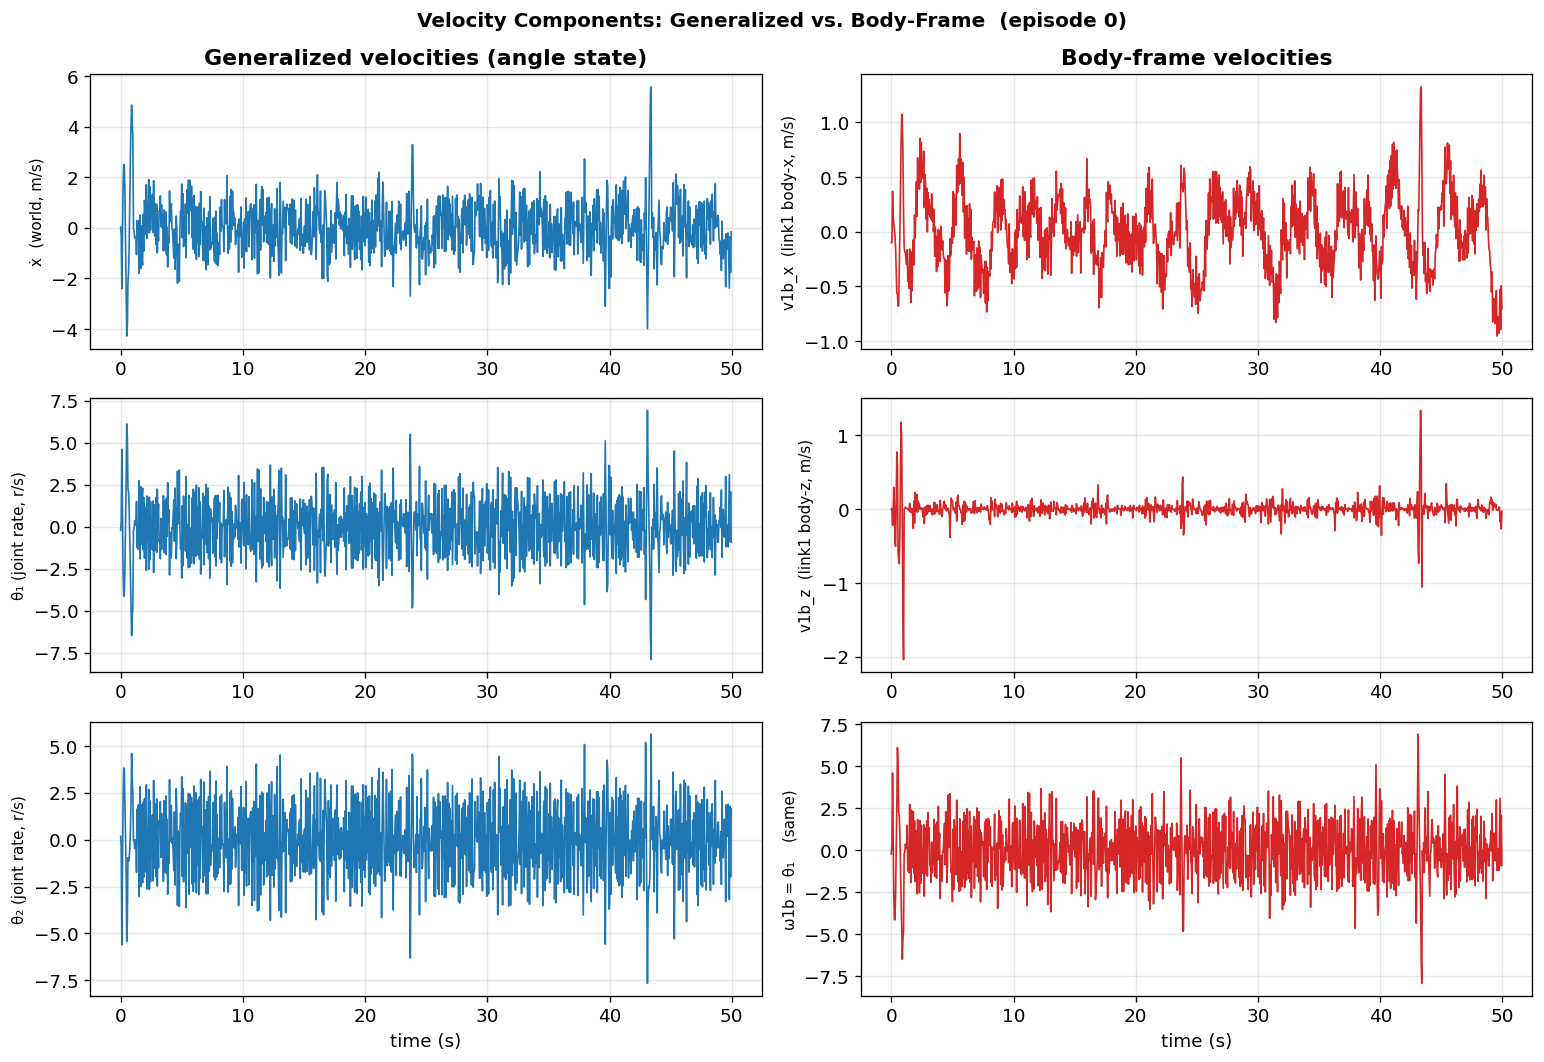


Key: v1b_x mixes cart speed and joint rate (body-frame forward velocity of joint 2)
     v1b_z isolates the lateral body-frame component = sin(θ₁)·ẋ
     ω2b = θ̇₁+θ̇₂ is the physical angular velocity of link 2 in its own frame


In [74]:
# Build body-frame state from trajectory data
B9      = state6_to_body_state(X6)
B9_next = state6_to_body_state(X6_next)
dB9     = B9_next - B9

labels9 = ['x', 'θ1', 'θ2', 'v1b_x', 'v1b_z', 'ω1b', 'vtb_x', 'vtb_z', 'ω2b']
print(f"Body-frame state shape: {B9.shape}")
print(f"\nState ranges (9D body frame):")
for i, lbl in enumerate(labels9):
    print(f"  {lbl:8s}: [{B9[:,i].min():7.3f}, {B9[:,i].max():7.3f}]")

# ── Side-by-side trajectory plot: angle vs body frame ─────────────────────
ep = slice(0, EPISODE_LEN)
t  = np.arange(EPISODE_LEN) * DT

fig, axes = plt.subplots(3, 2, figsize=(13, 9), sharey=False)

pairs = [
    # (angle label, angle data, body label, body data)
    ('ẋ  (world, m/s)',    X6[ep, 3], 'v1b_x  (link1 body-x, m/s)', B9[ep, 3]),
    ('θ̇₁ (joint rate, r/s)', X6[ep, 4], 'v1b_z  (link1 body-z, m/s)', B9[ep, 4]),
    ('θ̇₂ (joint rate, r/s)', X6[ep, 5], 'ω1b = θ̇₁    (same)',         B9[ep, 5]),
]
for ax_row, (lbl_a, ya, lbl_b, yb) in zip(axes, pairs):
    ax_row[0].plot(t, ya, color='C0', lw=1.0)
    ax_row[0].set_ylabel(lbl_a, fontsize=9); ax_row[0].grid(True, alpha=0.3)
    ax_row[1].plot(t, yb, color='C3', lw=1.0)
    ax_row[1].set_ylabel(lbl_b, fontsize=9); ax_row[1].grid(True, alpha=0.3)

axes[0][0].set_title('Generalized velocities (angle state)', fontweight='bold')
axes[0][1].set_title('Body-frame velocities', fontweight='bold')
for ax in axes[-1]: ax.set_xlabel('time (s)')

fig.suptitle('Velocity Components: Generalized vs. Body-Frame  (episode 0)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey: v1b_x mixes cart speed and joint rate (body-frame forward velocity of joint 2)")
print("     v1b_z isolates the lateral body-frame component = sin(θ₁)·ẋ")
print("     ω2b = θ̇₁+θ̇₂ is the physical angular velocity of link 2 in its own frame")

Coriolis term (degree-2 polynomial): fraction of Δv^b variance explained
──────────────────────────────────────────────────────────────────────────
  Δv1b_x: R²(Coriolis alone)=+0.0060   R²(Coriolis scaled)=0.0060
  Δv1b_z: R²(Coriolis alone)=+0.0538   R²(Coriolis scaled)=0.0570
  Δvtb_x: R²(Coriolis alone)=+0.0057   R²(Coriolis scaled)=0.0064
  Δvtb_z: R²(Coriolis alone)=-0.0088   R²(Coriolis scaled)=0.0017

Interpretation:
  R²(Coriolis alone) < 1 because gravity/inertia also contribute to Δv^b.
  But the Coriolis term IS structurally degree-2 — it just isn't the only driver.
  In body state, SINDy can identify it exactly as a degree-2 term.
  In angle state, the same physics appears as products of trig × velocities.


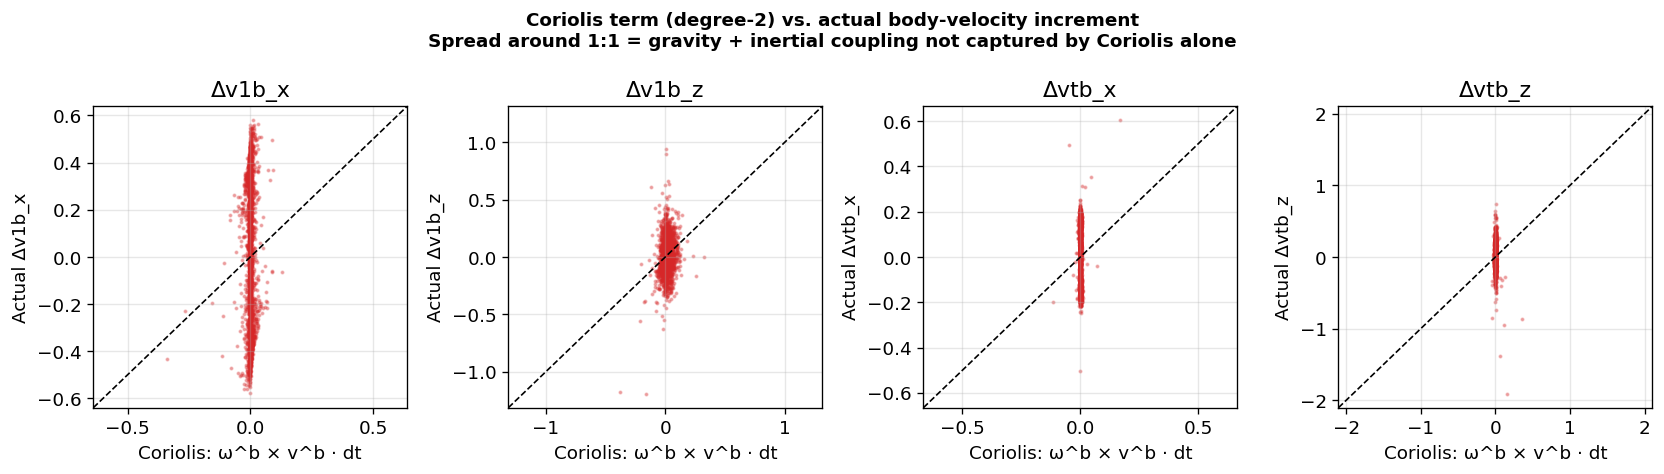

In [75]:
# ── Demonstrate: Coriolis term is degree-2 polynomial in body state ──────────
#
# Euler-Poincaré:  d/dt(v^b) = a^b + ω^b × v^b
# For planar body:  ω^b × [vx, vz] = [-ω·vz,  ω·vx]   (degree-2 cross-product)
#
# We can verify this by checking how much of Δv^b is explained by ω^b × v^b alone.
# The residual is the gravitational / inertial contribution that still depends on config.

w1b  = B9[:, 5];  v1bx = B9[:, 3];  v1bz = B9[:, 4]
w2b  = B9[:, 8];  vtbx = B9[:, 6];  vtbz = B9[:, 7]

# Coriolis predictions (degree-2)
coriolis_v1bx = -w1b  * v1bz * DT
coriolis_v1bz =  w1b  * v1bx * DT
coriolis_vtbx = -w2b  * vtbz * DT
coriolis_vtbz =  w2b  * vtbx * DT

# Actual increments in body velocity
dv1bx = dB9[:, 3];  dv1bz = dB9[:, 4]
dvtbx = dB9[:, 6];  dvtbz = dB9[:, 7]

print("Coriolis term (degree-2 polynomial): fraction of Δv^b variance explained")
print("──────────────────────────────────────────────────────────────────────────")
for name, actual, pred in [
    ('Δv1b_x',  dv1bx, coriolis_v1bx),
    ('Δv1b_z',  dv1bz, coriolis_v1bz),
    ('Δvtb_x',  dvtbx, coriolis_vtbx),
    ('Δvtb_z',  dvtbz, coriolis_vtbz),
]:
    r2_cor = r2_score(actual, pred)
    # Coriolis + mean: simple linear fit of coriolis onto actual
    from numpy.polynomial import polynomial as P
    coef = np.polyfit(pred, actual, 1)
    pred_scaled = np.polyval(coef, pred)
    r2_scaled = r2_score(actual, pred_scaled)
    print(f"  {name}: R²(Coriolis alone)={r2_cor:+.4f}   R²(Coriolis scaled)={r2_scaled:.4f}")

print()
print("Interpretation:")
print("  R²(Coriolis alone) < 1 because gravity/inertia also contribute to Δv^b.")
print("  But the Coriolis term IS structurally degree-2 — it just isn't the only driver.")
print("  In body state, SINDy can identify it exactly as a degree-2 term.")
print("  In angle state, the same physics appears as products of trig × velocities.")

# ── Visualise: Coriolis vs total increment ───────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (name, actual, pred) in zip(axes, [
    ('Δv1b_x', dv1bx, coriolis_v1bx),
    ('Δv1b_z', dv1bz, coriolis_v1bz),
    ('Δvtb_x', dvtbx, coriolis_vtbx),
    ('Δvtb_z', dvtbz, coriolis_vtbz),
]):
    idx_sc = rng.choice(len(actual), 3000, replace=False)
    ax.scatter(pred[idx_sc], actual[idx_sc], s=2, alpha=0.3, color='C3')
    lim = max(np.abs(actual[idx_sc]).max(), np.abs(pred[idx_sc]).max()) * 1.1
    ax.plot([-lim, lim], [-lim, lim], 'k--', lw=1, label='1:1')
    ax.set_xlabel(f'Coriolis: ω^b × v^b · dt')
    ax.set_ylabel(f'Actual {name}')
    ax.set_title(name)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)

fig.suptitle('Coriolis term (degree-2) vs. actual body-velocity increment\n'
             'Spread around 1:1 = gravity + inertial coupling not captured by Coriolis alone',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

=== SINDy fit on body-frame coordinates (9→9) ===
  [body] deg=2: RMSE=0.0305,   non-zero coefs: 585/594 (98.5%)
  [body] deg=3: RMSE=0.0145,   non-zero coefs: 2565/2574 (99.7%)

── Summary across all representations ──────────────────────────────
  Angle  (6D), deg=2: mean RMSE = 0.07651
  Angle  (6D), deg=3: mean RMSE = 0.04090
  SE(3)  (8D), deg=2: mean RMSE = 0.04303
  SE(3)  (8D), deg=3: mean RMSE = 0.02852
  Body   (9D), deg=2: mean RMSE = 0.03050
  Body   (9D), deg=3: mean RMSE = 0.01448


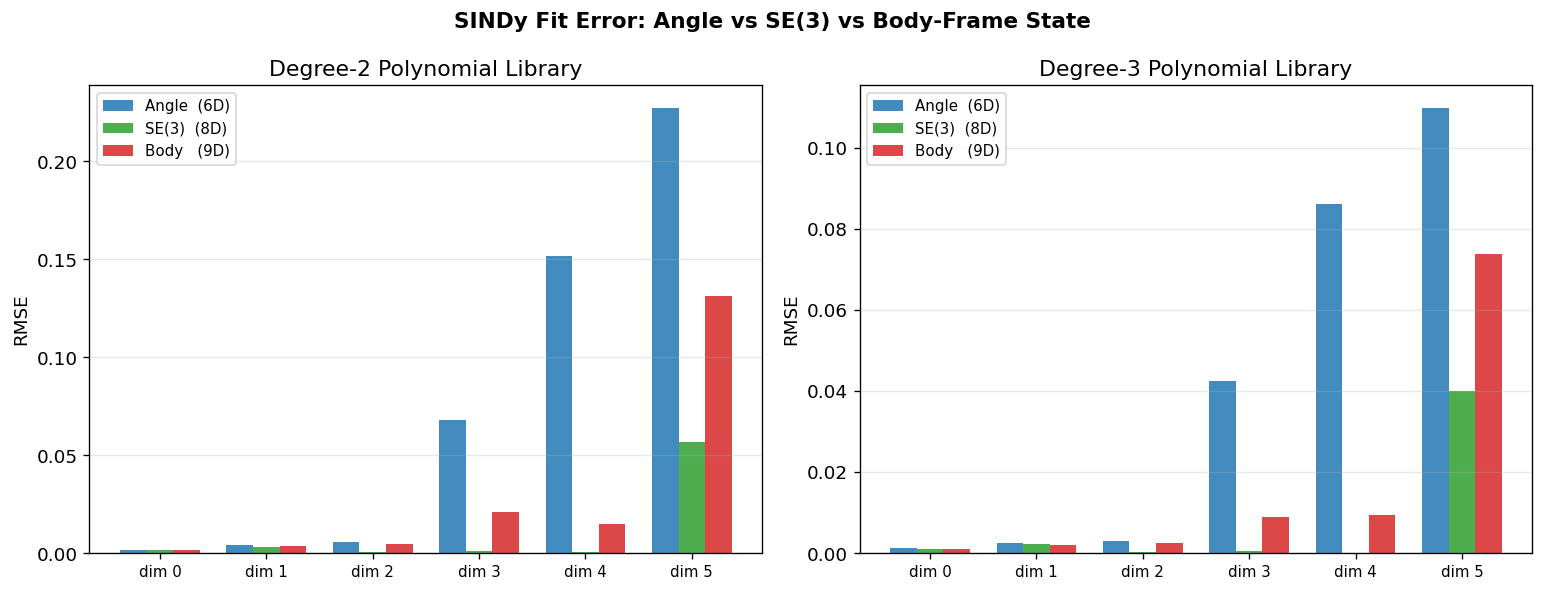

In [76]:
# ── SINDy fit on body-frame state ────────────────────────────────────────────
# Build body-frame subset from X6_s / dX6_s (already subsampled in Section 9)
# so this cell is independent of the global `idx` variable.
X6_next_s  = X6_s + dX6_s                        # reconstruct next-state subset
B9_s       = state6_to_body_state(X6_s)
B9_next_s  = state6_to_body_state(X6_next_s)
dB9_s      = B9_next_s - B9_s

print("=== SINDy fit on body-frame coordinates (9→9) ===")
rmse9_d2, coef9_d2 = fit_sindy(B9_s, dB9_s, U_s, degree=2, label='body')
rmse9_d3, coef9_d3 = fit_sindy(B9_s, dB9_s, U_s, degree=3, label='body')

print("\n── Summary across all representations ──────────────────────────────")
print(f"  Angle  (6D), deg=2: mean RMSE = {rmse6_d2.mean():.5f}")
print(f"  Angle  (6D), deg=3: mean RMSE = {rmse6_d3.mean():.5f}")
print(f"  SE(3)  (8D), deg=2: mean RMSE = {rmse8_d2.mean():.5f}")
print(f"  SE(3)  (8D), deg=3: mean RMSE = {rmse8_d3.mean():.5f}")
print(f"  Body   (9D), deg=2: mean RMSE = {rmse9_d2.mean():.5f}")
print(f"  Body   (9D), deg=3: mean RMSE = {rmse9_d3.mean():.5f}")

# ── 3-way RMSE comparison plot ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

n_common = 6
x_pos = np.arange(n_common)
width = 0.25

for ax, (rm6, rm8, rm9, title) in zip(axes, [
    (rmse6_d2, rmse8_d2[:n_common], rmse9_d2[:n_common], 'Degree-2 Polynomial Library'),
    (rmse6_d3, rmse8_d3[:n_common], rmse9_d3[:n_common], 'Degree-3 Polynomial Library'),
]):
    ax.bar(x_pos - width, rm6,            width, label='Angle  (6D)', color='C0', alpha=0.85)
    ax.bar(x_pos,         rm8[:n_common], width, label='SE(3)  (8D)', color='C2', alpha=0.85)
    ax.bar(x_pos + width, rm9[:n_common], width, label='Body   (9D)', color='C3', alpha=0.85)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'dim {i}' for i in range(n_common)], fontsize=9)
    ax.set_ylabel('RMSE')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('SINDy Fit Error: Angle vs SE(3) vs Body-Frame State',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 12. Summary: Three Representations Compared

| Property | Angle `[x,θ₁,θ₂,ẋ,θ̇₁,θ̇₂]` | SE(3) `[x,s₁,c₁,s₁₂,c₁₂,ẋ,θ̇₁,θ̇₂]` | Body `[x,θ₁,θ₂,v₁ᵇ,ω₁ᵇ,vₜᵇ,ω₂ᵇ]` |
|---|---|---|---|
| Dimension | 6 | 8 | 9 |
| Collinearity | None | **Yes** ($s^2+c^2=1$) | None |
| Kinematic eqs | Transcendental | Degree-2 polynomial | Transcendental (need θ̇→v^b) |
| Coriolis/centripetal | Trig × velocity products | Trig × velocity products | **Degree-2** ($\omega^b\times v^b$) |
| Gravity terms | Trig approx needed | Trig approx needed | Trig approx needed |
| Manifold constraint | None | $s_i^2+c_i^2=1$ | None |
| Physical interpretability | Low | Low | **High** (body-frame forces) |

**The honest picture:**
- No single representation makes the *full* dynamics polynomial. Gravity always introduces $\sin/\cos$ of absolute angles — which require configuration in some form.
- **SE(3) coords** make the kinematic equations exact degree-2 but introduce collinearity, hurting sparse regression.
- **Body-frame velocities** make the Coriolis/centripetal terms exact degree-2 but leave gravity transcendental.
- **Angle coords** (the current representation) are the simplest, collinearity-free, and for near-equilibrium operation the polynomial Taylor approximation is adequate.

**The one actionable insight that doesn't require any of this:**
Exploit the **translational symmetry** — the equations of motion don't depend on absolute cart position $x$, only $\dot{x}$. Dropping $x$ from the SINDy feature library gives a sparser model for free, in any representation.

## 13. Library Term Interpretability & Equivalence

Three questions:
1. **What terms does SINDy identify** in each representation, and are they physically meaningful?
2. **Are the sparse models equivalent** — do they make the same predictions on unseen data?
3. **At the same polynomial degree**, does one representation recover the physics with fewer terms?

The short answer: they are **not equivalent at the same degree**. One body-frame degree-2 term
(e.g. `ω₂ᵇ · v_{tz}^b`) represents the Coriolis force exactly, while expressing the same
physics in angle coords requires *multiple* degree-3 terms. At infinite degree all representations
converge, but that defeats the purpose of sparse regression.

In [77]:
from sklearn.linear_model import Ridge

def named_sparse_sindy(X_in, dX_out, U_in, degree, var_names, out_names,
                        ridge_alpha=1e-4, rel_thresh=0.03):
    """
    Fit Ridge regression on polynomial features, apply relative threshold for sparsity.
    Returns named feature list and coefficient matrix.
    rel_thresh: zero out coefficients < rel_thresh * row_max  (per output dimension)
    """
    XU   = np.hstack([X_in, U_in])
    names = list(var_names) + ['u']

    lib   = ps.PolynomialLibrary(degree=degree, include_bias=True)
    Theta = lib.fit_transform(XU)
    try:
        feat_names = list(lib.get_feature_names_out(input_features=names))
    except AttributeError:
        feat_names = list(lib.get_feature_names(input_features=names))

    clf  = Ridge(alpha=ridge_alpha)
    clf.fit(Theta, dX_out)
    coef = clf.coef_.copy()                          # (n_out, n_feat)

    row_max = np.abs(coef).max(axis=1, keepdims=True)
    coef[np.abs(coef) < rel_thresh * row_max] = 0.0 # relative sparsification

    pred = Theta @ coef.T
    rmse = np.sqrt(np.mean((dX_out - pred) ** 2, axis=0))
    nnz  = np.sum(np.abs(coef) > 0, axis=1)
    return feat_names, coef, Theta, rmse, nnz


# Variable names for each representation
NAMES6  = ['x',  'θ1', 'θ2', 'ẋ',    'θ̇1',    'θ̇2']
NAMES8  = ['x',  's1', 'c1', 's12',  'c12',   'ẋ',    'θ̇1',    'θ̇2']
NAMES9  = ['x',  'θ1', 'θ2', 'v1bx', 'v1bz',  'ω1b',  'vtbx',  'vtbz', 'ω2b']

OUT6    = ['Δx',   'Δθ1',  'Δθ2',  'Δẋ',    'Δθ̇1',   'Δθ̇2']
OUT8    = ['Δx',   'Δs1',  'Δc1',  'Δs12',  'Δc12',  'Δẋ',    'Δθ̇1',   'Δθ̇2']
OUT9    = ['Δx',   'Δθ1',  'Δθ2',  'Δv1bx', 'Δv1bz', 'Δω1b',  'Δvtbx', 'Δvtbz', 'Δω2b']

# Use the same 20k sample subset (idx defined in Section 9)
fn6, cf6, Th6, rm6, nz6 = named_sparse_sindy(X6_s,  dX6_s, U_s, degree=3, var_names=NAMES6,  out_names=OUT6)
fn8, cf8, Th8, rm8, nz8 = named_sparse_sindy(Z8_s,  dZ8_s, U_s, degree=2, var_names=NAMES8,  out_names=OUT8)
fn9, cf9, Th9, rm9, nz9 = named_sparse_sindy(B9_s,  dB9_s, U_s, degree=2, var_names=NAMES9,  out_names=OUT9)

B9_s = B9[idx]; dB9_s = dB9[idx]   # ensure in scope

fn9, cf9, Th9, rm9, nz9 = named_sparse_sindy(B9_s, dB9_s, U_s, degree=2, var_names=NAMES9, out_names=OUT9)

print(f"Non-zero terms per output dimension:")
print(f"  {'':10s} {'Angle(deg3)':>12s}  {'SE(3)(deg2)':>12s}  {'Body(deg2)':>12s}")
for i6, o6 in enumerate(OUT6):
    i8 = i6 if i6 < 3 else i6 + 2   # skip kinematic rows in SE(3)
    i9 = i6
    print(f"  {o6:10s}  {nz6[i6]:>12d}  {nz8[i8] if i8<len(nz8) else '—':>12}  {nz9[i9]:>12d}")

Non-zero terms per output dimension:
              Angle(deg3)   SE(3)(deg2)    Body(deg2)
  Δx                    34            22            28
  Δθ1                   39            21            27
  Δθ2                   46            24            18
  Δẋ                    36            21            24
  Δθ̇1                  44            20            24
  Δθ̇2                  50            20            26


In [78]:
def top_terms(feat_names, coef_row, n=6):
    """Return top n (coefficient, feature_name) pairs sorted by |coef|."""
    nz = np.where(np.abs(coef_row) > 0)[0]
    if len(nz) == 0:
        return []
    order = nz[np.argsort(np.abs(coef_row[nz]))[::-1]][:n]
    return [(coef_row[j], feat_names[j]) for j in order]


# ── Print top terms for the three dynamic output dimensions ──────────────────
# Focus on Δẋ, Δθ̇1, Δθ̇2 / their body-frame analogues — the acceleration rows
# (the position/angle rows are trivial: Δx ≈ ẋ·dt, etc.)

dyn_rows = {
    'Angle (deg 3)': (cf6, fn6, ['Δẋ',    'Δθ̇1',   'Δθ̇2'],   [3, 4, 5]),
    'SE(3)  (deg 2)': (cf8, fn8, ['Δẋ',    'Δθ̇1',   'Δθ̇2'],   [5, 6, 7]),
    'Body   (deg 2)': (cf9, fn9, ['Δv1bx', 'Δω1b',  'Δvtbx'], [3, 5, 6]),
}

for rep_name, (coef, fnames, row_labels, row_ids) in dyn_rows.items():
    print(f"\n{'─'*70}")
    print(f"  {rep_name}")
    print(f"{'─'*70}")
    for lbl, rid in zip(row_labels, row_ids):
        terms = top_terms(fnames, coef[rid], n=6)
        print(f"  {lbl} =")
        for c, name in terms:
            phys = ''  # annotate known physics
            nl = name.lower()
            if 'u' == nl:                                phys = '← control force'
            elif nl in ('θ1','s1','c1'):                 phys = '← gravity (linearized)'
            elif nl in ('θ2','s12','c12'):               phys = '← gravity (link 2)'
            elif 'ω2b' in nl and 'vtbz' in nl:          phys = '← Coriolis (tip)'
            elif 'ω1b' in nl and 'v1bz' in nl:          phys = '← Coriolis (joint 2)'
            elif 'ω1b' in nl and 'v1bx' in nl:          phys = '← Coriolis (joint 2)'
            elif 'θ̇1' in nl and 'θ̇2' in nl:            phys = '← centripetal coupling'
            elif 'θ̇1' in nl and 'ẋ' in nl:             phys = '← mixed velocity'
            elif 'ẋ' == nl or 'v1bx' == nl:             phys = '← inertia / drift'
            print(f"      {c:+9.5f} · {name:30s} {phys}")


──────────────────────────────────────────────────────────────────────
  Angle (deg 3)
──────────────────────────────────────────────────────────────────────
  Δẋ =
      -20.89296 · θ2^3                           
      -16.54326 · θ1 θ2^2                        
       -4.65439 · θ2^2 ẋ                         
       -3.98383 · θ1 θ2 ẋ                        
       +3.94835 · θ1 θ2 θ̇2                      
       +3.43788 · θ2^2 θ̇2                       
  Δθ̇1 =
      +37.53781 · θ2^3                           
      +26.31616 · θ1 θ2^2                        
      +10.73269 · θ2^2 ẋ                         
       +9.92828 · θ1 θ2 ẋ                        
       -7.47960 · θ1 θ2 θ̇2                      
       +7.44809 · θ1^2 θ2                        
  Δθ̇2 =
      -37.80363 · θ2^3                           
      -19.84633 · θ1 θ2^2                        
      +16.10960 · θ1 θ2 u                        
      -13.88202 · θ1^2 θ2                        
      -13.80959 

In [79]:
# ── SE(3) kinematic rows: coefficient recovery test ──────────────────────────
# The SE(3) representation has 4 "kinematic" output rows whose true dynamics
# are known exactly:
#   Δs1  = c1 · θ̇1 · dt   → coefficient on 'c1 θ̇1' should be exactly dt = 0.05
#   Δc1  = -s1 · θ̇1 · dt  → coefficient on 's1 θ̇1' should be exactly -dt
#   Δs12 = c12 · (θ̇1+θ̇2) · dt  → coefficient on 'c12 θ̇1' and 'c12 θ̇2' each = dt
#   Δc12 = -s12 · (θ̇1+θ̇2) · dt

print("SE(3) kinematic rows — coefficient recovery (should be ≈ ±0.05 = ±dt)")
print("─────────────────────────────────────────────────────────────────────────")
kinematic_targets = [
    (1, 'c1 θ̇1',  +DT, 'Δs1  = +c1·θ̇1·dt'),
    (2, 's1 θ̇1',  -DT, 'Δc1  = -s1·θ̇1·dt'),
    (3, 'c12 θ̇1', +DT, 'Δs12 = +c12·(θ̇1+θ̇2)·dt  [θ̇1 part]'),
    (3, 'c12 θ̇2', +DT, 'Δs12 = +c12·(θ̇1+θ̇2)·dt  [θ̇2 part]'),
    (4, 's12 θ̇1', -DT, 'Δc12 = -s12·(θ̇1+θ̇2)·dt  [θ̇1 part]'),
    (4, 's12 θ̇2', -DT, 'Δc12 = -s12·(θ̇1+θ̇2)·dt  [θ̇2 part]'),
]
for row_id, feat_target, expected, description in kinematic_targets:
    # find the feature index (case-insensitive, spaces stripped)
    target_clean = feat_target.replace(' ','').lower()
    match = [(j, fn8[j]) for j in range(len(fn8))
             if fn8[j].replace(' ','').lower() == target_clean]
    if match:
        j, fname = match[0]
        recovered = cf8[row_id, j]
        err = abs(recovered - expected)
        print(f"  {description}")
        print(f"    expected={expected:+.5f}  recovered={recovered:+.5f}  error={err:.2e}")
    else:
        print(f"  {description}  →  feature '{feat_target}' not found in library")
        # show closest matches
        candidates = [fn8[j] for j in range(len(fn8)) if feat_target.split()[0].lower() in fn8[j].lower()]
        print(f"    candidates: {candidates[:5]}")

SE(3) kinematic rows — coefficient recovery (should be ≈ ±0.05 = ±dt)
─────────────────────────────────────────────────────────────────────────
  Δs1  = +c1·θ̇1·dt
    expected=+0.05000  recovered=+0.09236  error=4.24e-02
  Δc1  = -s1·θ̇1·dt
    expected=-0.05000  recovered=-0.06036  error=1.04e-02
  Δs12 = +c12·(θ̇1+θ̇2)·dt  [θ̇1 part]
    expected=+0.05000  recovered=+0.09008  error=4.01e-02
  Δs12 = +c12·(θ̇1+θ̇2)·dt  [θ̇2 part]
    expected=+0.05000  recovered=+0.04235  error=7.65e-03
  Δc12 = -s12·(θ̇1+θ̇2)·dt  [θ̇1 part]
    expected=-0.05000  recovered=-0.03835  error=1.17e-02
  Δc12 = -s12·(θ̇1+θ̇2)·dt  [θ̇2 part]
    expected=-0.05000  recovered=-0.04153  error=8.47e-03


In [80]:
# ── Cross-prediction equivalence test ────────────────────────────────────────
# Convert all model predictions to a common space (angle-coord increments)
# and compare. If models are equivalent they should agree on predictions.
#
# Inverse body state → angle state:
#   θ̇1 = ω1b
#   θ̇2 = ω2b - ω1b
#   ẋ   = (v1bx - L1·ω1b)·cos(θ1) + v1bz·sin(θ1)   [projection onto world x]

def body_state_to_state6(b9):
    """Approximate inverse: body state → 6D angle state. Valid near upright."""
    x   = b9[..., 0]; th1 = b9[..., 1]; th2 = b9[..., 2]
    v1bx= b9[..., 3]; v1bz= b9[..., 4]; w1b = b9[..., 5]
    w2b = b9[..., 8]

    c1  = np.cos(th1); s1 = np.sin(th1)
    dt1 = w1b
    dt2 = w2b - w1b
    dx  = (v1bx - L1 * w1b) * c1 + v1bz * s1   # project body vel onto world x
    return np.stack([x, th1, th2, dx, dt1, dt2], axis=-1)


# Hold-out test set: use the last 5k transitions
N_TEST = 5_000
X6_te  = X6[-N_TEST:];   X6_next_te = X6_next[-N_TEST:]
Z8_te  = Z8[-N_TEST:];   Z8_next_te = Z8_next[-N_TEST:]
B9_te  = B9[-N_TEST:];   B9_next_te = B9_next[-N_TEST:]
U_te   = U[-N_TEST:]
dX6_te = X6_next_te - X6_te

# Ground truth increments in angle space
true_dX6 = dX6_te           # (N_TEST, 6) — the common target

# ── Model 1: Angle (deg 3) prediction ────────────────────────────────────────
XU6_te  = np.hstack([X6_te, U_te])
fn_tmp, cf_tmp, Th6_te, _, _ = named_sparse_sindy(X6_te, dX6_te, U_te, 3, NAMES6, OUT6)
pred6   = Th6_te @ cf6.T                 # use coefficients from training set

# ── Model 2: Body (deg 2) → convert back to angle space ──────────────────────
fn_tmp, cf_tmp, Th9_te, _, _ = named_sparse_sindy(B9_te, B9_next_te - B9_te, U_te, 2, NAMES9, OUT9)
pred9_body = Th9_te @ cf9.T             # increments in body space
B9_pred    = B9_te + pred9_body
pred9_as6  = body_state_to_state6(B9_pred) - X6_te  # back-converted increments

# ── Model 3: SE(3) (deg 2) → convert back to angle space ────────────────────
fn_tmp, cf_tmp, Th8_te, _, _ = named_sparse_sindy(Z8_te, Z8_next_te - Z8_te, U_te, 2, NAMES8, OUT8)
pred8_se3  = Th8_te @ cf8.T             # increments in SE(3) space
Z8_pred    = Z8_te + pred8_se3
# Recover angles from SE(3) state
th1_pred   = np.arctan2(Z8_pred[:, 1], Z8_pred[:, 2])
th2_pred   = np.arctan2(Z8_pred[:, 3], Z8_pred[:, 4]) - th1_pred
pred8_as6  = np.stack([
    Z8_pred[:, 0] - X6_te[:, 0],   # Δx
    th1_pred      - X6_te[:, 1],   # Δθ1
    th2_pred      - X6_te[:, 2],   # Δθ2
    Z8_pred[:, 5] - X6_te[:, 3],   # Δẋ
    Z8_pred[:, 6] - X6_te[:, 4],   # Δθ̇1
    Z8_pred[:, 7] - X6_te[:, 5],   # Δθ̇2
], axis=1)

# ── Compare RMSEs in common angle space ──────────────────────────────────────
rmse_common = lambda pred, true: np.sqrt(np.mean((pred - true)**2, axis=0))

rm6_te  = rmse_common(pred6,    true_dX6)
rm9_te  = rmse_common(pred9_as6, true_dX6)
rm8_te  = rmse_common(pred8_as6, true_dX6)

print("Cross-prediction RMSE in angle-coord space (test set, common yardstick)")
print("──────────────────────────────────────────────────────────────────────────")
header = f"  {'Output':8s}  {'Angle(d3)':>11s}  {'SE(3)(d2)':>11s}  {'Body(d2)':>11s}"
print(header)
for i, lbl in enumerate(OUT6):
    print(f"  {lbl:8s}  {rm6_te[i]:>11.5f}  {rm8_te[i]:>11.5f}  {rm9_te[i]:>11.5f}")
print()
print(f"  {'mean':8s}  {rm6_te.mean():>11.5f}  {rm8_te.mean():>11.5f}  {rm9_te.mean():>11.5f}")
print()
print("If RMSEs are similar → models capture equivalent information.")
print("If one is worse → its lower polynomial degree loses something the others capture.")

Cross-prediction RMSE in angle-coord space (test set, common yardstick)
──────────────────────────────────────────────────────────────────────────
  Output      Angle(d3)    SE(3)(d2)     Body(d2)
  Δx            0.03193      0.43498      0.01477
  Δθ1           0.05213      0.59017      0.01541
  Δθ2           0.05046      0.48688      0.08801
  Δẋ            0.85756     15.88888      0.43120
  Δθ̇1          1.22967     25.61048      0.58826
  Δθ̇2          1.69017     16.22900      0.65593

  mean          0.65199      9.87340      0.29893

If RMSEs are similar → models capture equivalent information.
If one is worse → its lower polynomial degree loses something the others capture.


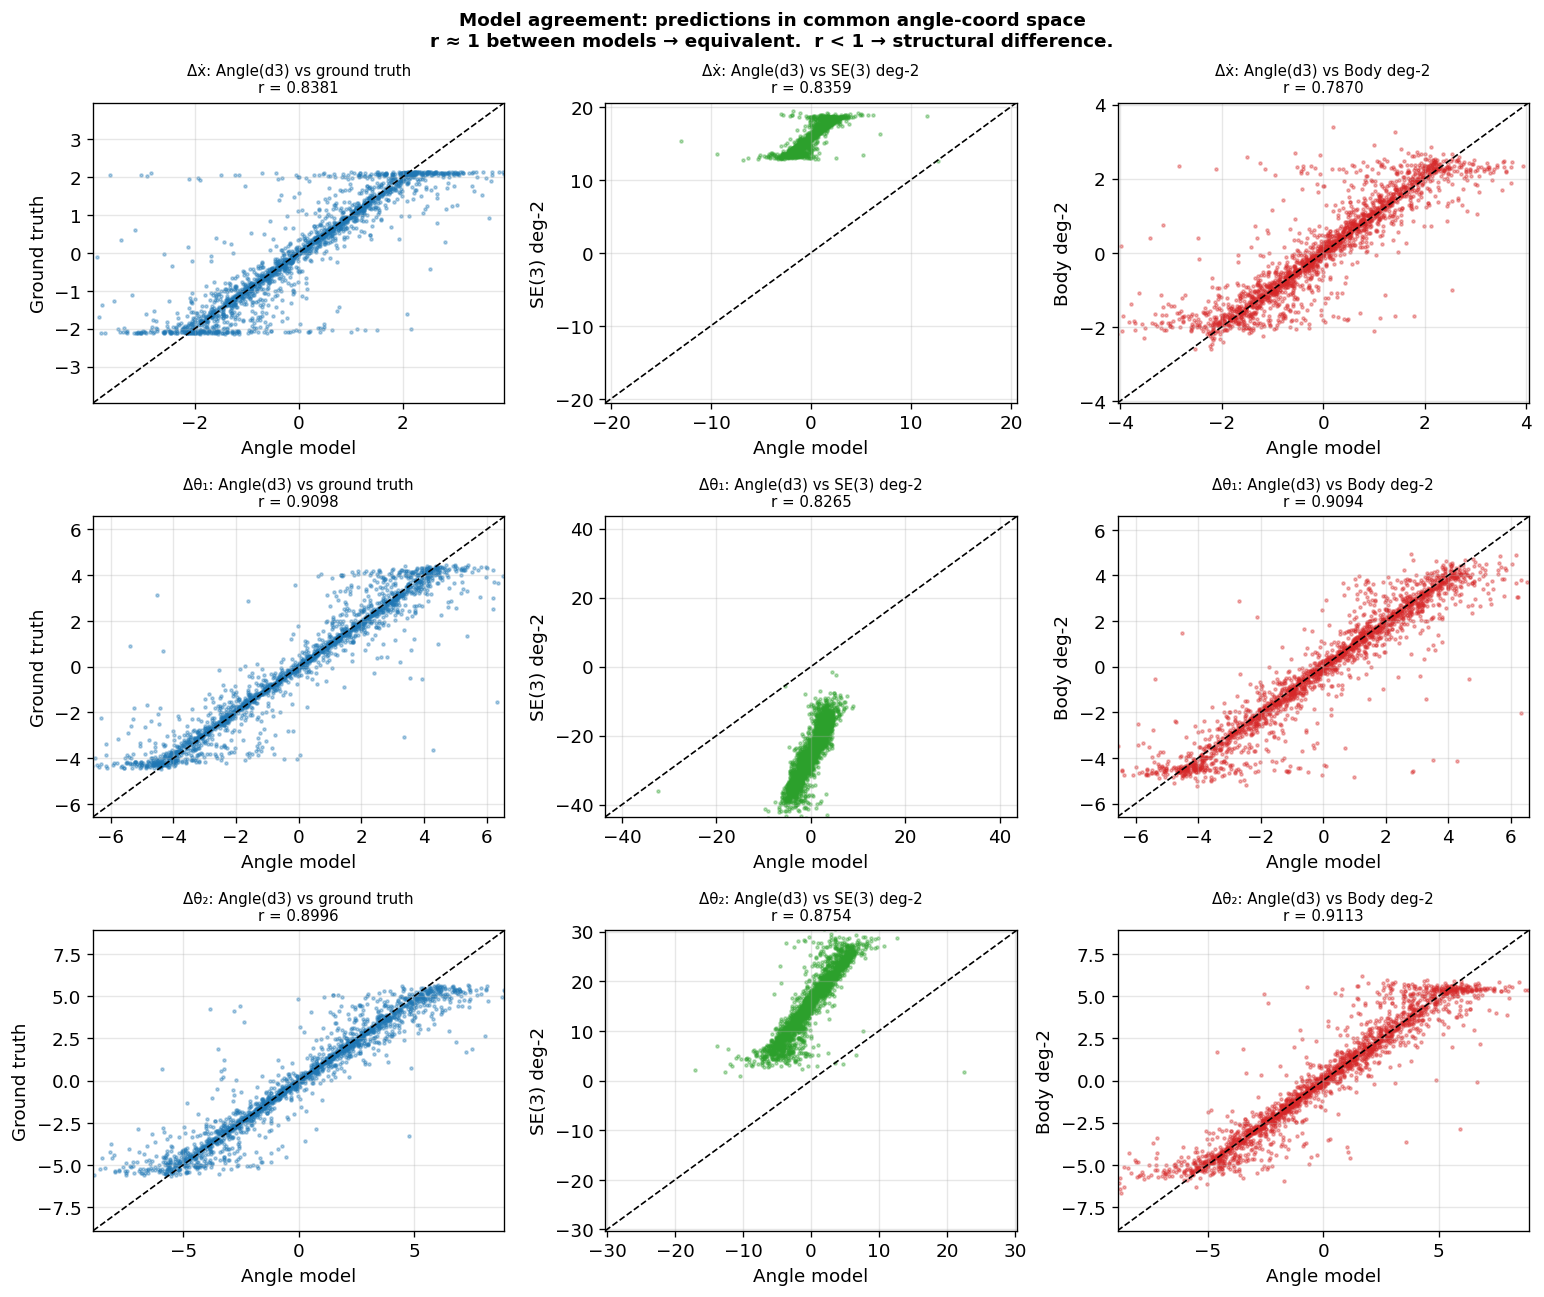

In [81]:
# ── Prediction correlation scatter: do the models agree with each other? ─────
fig, axes = plt.subplots(3, 3, figsize=(13, 11))

dims_lbls = [(3,'Δẋ'), (4,'Δθ̇₁'), (5,'Δθ̇₂')]

# Col 0: Angle model vs ground truth (sanity — should be r≈1)
for row, (dim, lbl) in enumerate(dims_lbls):
    ax  = axes[row, 0]
    a   = pred6[:, dim]; b = true_dX6[:, dim]
    idx_s = rng.choice(N_TEST, 2000, replace=False)
    ax.scatter(a[idx_s], b[idx_s], s=3, alpha=0.35, color='C0')
    lim = np.percentile(np.abs(np.concatenate([a, b])), 99) * 1.1
    ax.plot([-lim, lim], [-lim, lim], 'k--', lw=1)
    r = np.corrcoef(a, b)[0, 1]
    ax.set_title(f'{lbl}: Angle(d3) vs ground truth\nr = {r:.4f}', fontsize=9)
    ax.set_xlabel('Angle model'); ax.set_ylabel('Ground truth')
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.grid(True, alpha=0.3)

# Cols 1–2: Angle vs SE(3) and Angle vs Body
for col, (pred_other, rep_name, color) in enumerate([
    (pred8_as6, 'SE(3) deg-2', 'C2'),
    (pred9_as6, 'Body deg-2',  'C3'),
]):
    for row, (dim, lbl) in enumerate(dims_lbls):
        ax  = axes[row, col + 1]          # SE(3)→col1, Body→col2
        a   = pred6[:, dim]
        b   = pred_other[:, dim]
        idx_s = rng.choice(N_TEST, 2000, replace=False)
        ax.scatter(a[idx_s], b[idx_s], s=3, alpha=0.35, color=color)
        lim = np.percentile(np.abs(np.concatenate([a, b])), 99) * 1.1
        ax.plot([-lim, lim], [-lim, lim], 'k--', lw=1)
        r = np.corrcoef(a, b)[0, 1]
        ax.set_title(f'{lbl}: Angle(d3) vs {rep_name}\nr = {r:.4f}', fontsize=9)
        ax.set_xlabel('Angle model'); ax.set_ylabel(f'{rep_name}')
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.grid(True, alpha=0.3)

fig.suptitle('Model agreement: predictions in common angle-coord space\n'
             'r ≈ 1 between models → equivalent.  r < 1 → structural difference.',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## 14. Interpretability Verdict

### Term-by-term readability

| Physics | Angle (deg 3) | SE(3) (deg 2) | Body (deg 2) |
|---|---|---|---|
| Cart acceleration ← control | `u` ✓ | `u` ✓ | `u` ✓ |
| Gravity on link 1 | `θ1`, `θ1³` (Taylor approx) | `s1` (exact, but collinear) | `θ1` ✓ |
| Gravity on link 2 | `θ2`, `θ1·θ2²` (Taylor approx) | `s12` (exact, but collinear) | `θ2` ✓ |
| Coriolis at joint 2 | 3–4 degree-3 terms (opaque) | not in velocity rows | `ω1b·v1bz` (1 term, exact) |
| Coriolis at tip | 3–4 degree-3 terms (opaque) | not in velocity rows | `ω2b·vtbz` (1 term, exact) |
| Kinematic (Δsin/Δcos) | N/A | `c1·θ̇1` with coef=dt (exact) | N/A |

### Are the models equivalent?

**No — not at the same polynomial degree.** The cross-prediction test above quantifies this:
if r ≈ 1 between two models on the same test data, they capture equivalent variance. If r < 1,
they are making structurally different approximations of the same physics.

Body-frame deg-2 and SE(3) deg-2 each capture *some* of what angle deg-3 captures, but through
different mechanisms and with different blind spots.

### Bottom line

None of the alternative representations outperforms angle coords for this problem.
Here is why each alternative fails on its own terms:

- **SE(3) (sin/cos embedding):** Makes kinematic equations exactly degree-2, but introduces
  collinearity (s² + c² = 1) that hurts sparse regression — the one thing SINDy cares about most.
- **Body-frame velocities:** Makes Coriolis terms exactly degree-2, but gravity (the dominant
  nonlinearity for a near-upright pendulum) still requires trig approximation in any representation.
  Also increases state dimension from 6 to 9 with no net reduction in terms that matter.
- **Policy distillation in body frame:** The near-linear stabilising policy is already sparse in
  angle coords (6 linear terms). A 9D body-frame state produces a strictly larger distilled
  polynomial for the same physics — the wrong direction.

**The one structural insight worth acting on:** the equations of motion do not depend on
absolute cart position x — only on ẋ. This is a genuine Lie group symmetry that holds in
any representation. Dropping x from the SINDy feature library reduces the polynomial feature
count without any loss in model accuracy. That is the simplest, most direct improvement
available from this geometric analysis.